1、对MKFGO数据集进行分析
结论：从数据_label的角度来看，训练集中存在一定数量的低频训练数据，没有被剔除

In [18]:
import utils

# 使用示例
class_name = 'CC'
train_frequency = utils.count_occurrences('./data/'+class_name+'/train_gene_label', './data/'+class_name+'/term_list')
test_frequency = utils.count_occurrences('./data/'+class_name+'/evaluate_gene_label', './data/'+class_name+'/term_list')
eval_frequency = utils.count_occurrences('./data/'+class_name+'/test_gene_label', './data/'+class_name+'/term_list')

print('ID', 'train', 'test', 'eval')
for key in train_frequency.keys():
    train_f = train_frequency[key]
    test_f = test_frequency[key]
    eval_f = eval_frequency[key]
    if int(train_f)<=10 and (int(test_f)!=0 or int(eval_f)!=0): # 训练集中出现频率小于等于10的，且测试集和验证集不为0的go term及注释到的蛋白质情况
        print(f'{key}, {train_f:>6}, {test_f:>6}, {eval_f:>6}')

/home/fengtianyu@corp.sse.tongji.edu.cn/.conda/envs/synergy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ID train test eval
GO:0000811,     10,      3,      0
GO:0016513,      7,      0,      2
GO:0009328,      2,      0,      2
GO:0009317,      5,      3,      0
GO:0043655,      9,      0,      2
GO:0020009,      2,      1,      0
GO:0019029,      4,      0,      6
GO:0031472,      6,      0,     11
GO:0033254,      4,      0,      1
GO:0009275,      5,      3,      0
GO:0099569,     10,      1,      0
GO:0097232,      4,      1,      0
GO:0097233,      3,      1,      0
GO:0000934,      1,      0,      2
GO:0043657,      5,      3,      1
GO:1990578,      8,      1,      0
GO:0036128,     10,      0,      4
GO:0020015,      9,      0,      1
GO:0110071,      1,      0,      1
GO:1903144,      1,      0,      1
GO:0020020,      6,      0,      9
GO:0098591,      4,      1,      0
GO:0043036,      6,      0,      2
GO:0030287,      8,      1,      0
GO:0044308,      3,      0,      1
GO:0098892,      9,      1,      0
GO:0099147,      7,      1,      0
GO:0044217,      7,      0,      1
G

2、对MKFGO数据集进行分析
结论：**term_list存的是训练集中有的go term。**
只在test和eval中特有的go term，不在term_list中。因此term_list为待预测的go term.

In [21]:
import os
from collections import defaultdict

def merge_goa(file_paths):
    protein_goa = defaultdict(list)
    
    for path in file_paths:
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:               # 跳过空行
                    continue
                parts = line.split(maxsplit=1)  # 以第一个空格为界分为蛋白ID和GOA部分
                if len(parts) != 2:
                    continue
                prot_id, goa_str = parts
                # 按逗号拆分GOA，并过滤空字符串
                goa_list = [g.strip() for g in goa_str.split(',') if g.strip()]
                protein_goa[prot_id].extend(goa_list)

    return dict(protein_goa)

namespace = 'CC'
result = merge_goa(['./data/'+namespace+'/train_gene_label', './data/'+namespace+'/test_gene_label', './data/'+namespace+'/evaluate_gene_label'])
all_set = {elem for lst in result.values() for elem in lst}

term_set = set()
with open('./data/'+namespace+'/term_list', 'r') as f:
    for line in f:
        term_set.add(line.strip())

print(all_set-term_set)

test_eval_set = {elem for lst in (merge_goa(['./data/'+namespace+'/test_gene_label', './data/'+namespace+'/evaluate_gene_label']).values()) for elem in lst}
train_set = {elem for lst in (merge_goa(['./data/'+namespace+'/train_gene_label']).values()) for elem in lst}
print(test_eval_set-train_set)
print((all_set-term_set) - (test_eval_set-train_set))
print((test_eval_set-train_set)- (all_set-term_set))

print(train_set-term_set, term_set-train_set)

{'GO:0044796', 'GO:0033163', 'GO:0042151', 'GO:0097619', 'GO:0120202', 'GO:0097570', 'GO:0062074', 'GO:0085039', 'GO:0061823', 'GO:0031910', 'GO:0043626', 'GO:0020022', 'GO:0140266', 'GO:0060111'}
{'GO:0044796', 'GO:0033163', 'GO:0042151', 'GO:0097619', 'GO:0120202', 'GO:0097570', 'GO:0062074', 'GO:0085039', 'GO:0061823', 'GO:0031910', 'GO:0043626', 'GO:0020022', 'GO:0140266', 'GO:0060111'}
set()
set()
set() set()


3、二阶段日志

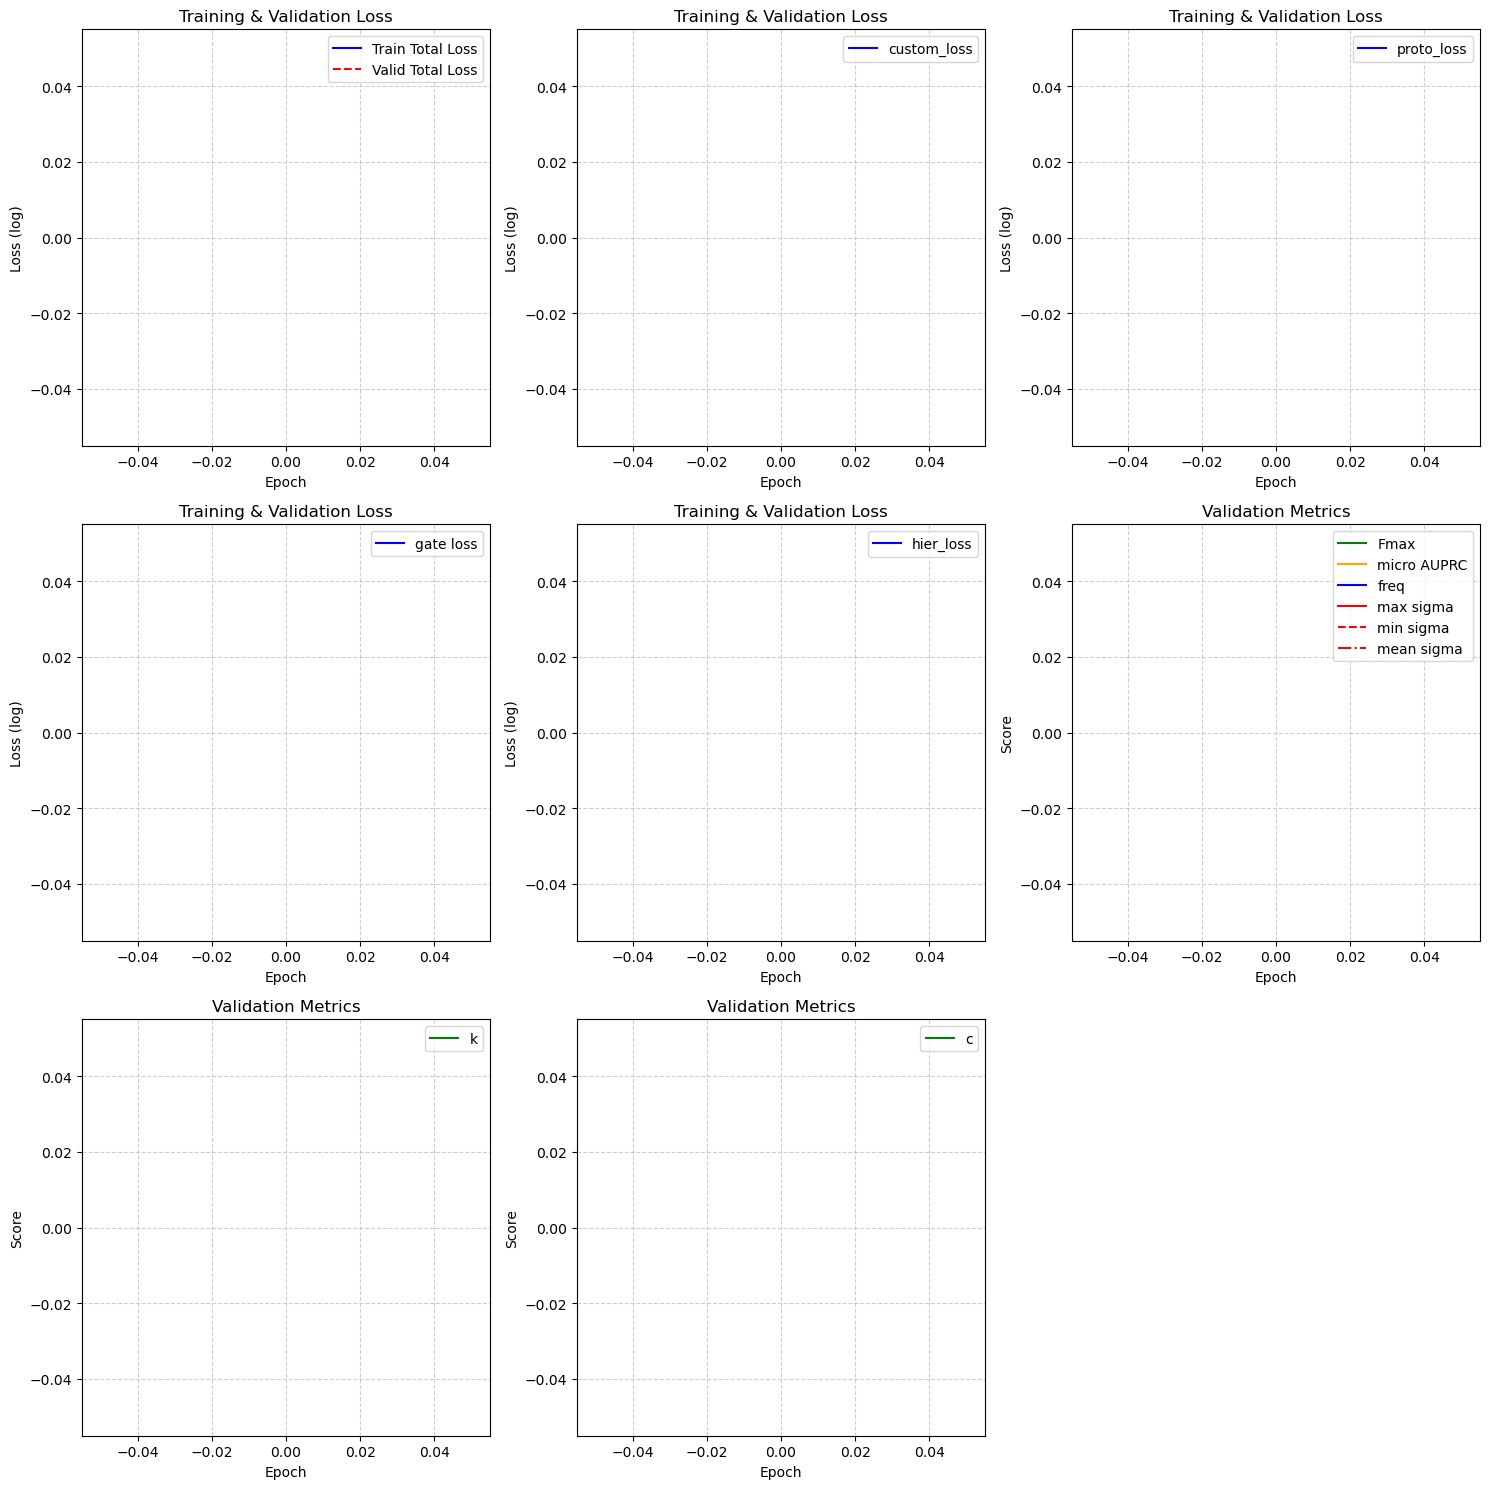

In [19]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    train_loss, val_loss, proto_loss, gate_loss, custom_loss, hier_loss  = [], [], [], [], [], []
    k, c, fmax, micro_auprc, max_sigma, min_sigma, mean_sigma, freq = [], [], [], [], [], [], [], []

    # 定义正则匹配模式
    train_pattern = re.compile(r"Averaged stats: .* total_loss: ([\d.eE+-]+)")
    val_pattern = re.compile(r"Averaged stats\(Valid\):\s+total_loss:\s+([\d.eE+-]+)\s+custom_loss:\s+([\d.eE+-]+)\s+proto_loss:\s+([\d.eE+-]+)\s+gate_loss:\s+([\d.eE+-]+)\s+hier_loss:\s+([\d.eE+-]+)\s+max_sigma:\s+([\d.eE+-]+)\s+min_sigma:\s+([\d.eE+-]+)\s+mean_sigma:\s+([\d.eE+-]+)\s+k:\s+([\d.eE+-]+)\s+c:\s+([\d.eE+-]+),\s+Fmax:\s+([\d.eE+-]+),\s+micro AUPRC:\s+([\d.eE+-]+),\s+target frequency:\s+([\d.eE+-]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = val_pattern.search(line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                custom_loss.append(float(val_match.group(2)))
                proto_loss.append(float(val_match.group(3)))
                gate_loss.append(float(val_match.group(4)))
                hier_loss.append(float(val_match.group(5)))
                max_sigma.append(float(val_match.group(6)))
                min_sigma.append(float(val_match.group(7)))
                mean_sigma.append(float(val_match.group(8)))
                k.append(float(val_match.group(9)))
                c.append(float(val_match.group(10)))
                fmax.append(float(val_match.group(11)))
                micro_auprc.append(float(val_match.group(12)))
                freq.append(float(val_match.group(13)))
                continue # 匹配到 Valid 后跳过，防止被下方 Train 模式二次匹配
            
            train_match = train_pattern.search(line)
            if train_match:
                train_loss.append(float(train_match.group(1)))

    # 对数化处理以更清晰地展示损失变化趋势
    eps = 1e-8
    train_loss = [np.log(x + eps) for x in train_loss]
    val_loss = [np.log(x + eps) for x in val_loss]
    # hier_loss = [np.log(x + eps) for x in hier_loss]
    # custom_loss = [np.log(x + eps) for x in custom_loss]
    # gate_loss = [np.log(x + eps) for x in gate_loss]
    # proto_loss = [np.log(x + eps) for x in proto_loss]

    epochs = range(1, len(train_loss) + 1)
    # 开始绘图
    plt.figure(figsize=(15, 15))

    plt.subplot(3, 3, 1)
    plt.plot(epochs, train_loss, label='Train Total Loss', color='blue')
    plt.plot(epochs, val_loss, label='Valid Total Loss', color='red', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 2)
    plt.plot(epochs, custom_loss, label='custom_loss', color='blue')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 3)
    plt.plot(epochs, proto_loss, label='proto_loss', color='blue')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 4)
    plt.plot(epochs, gate_loss, label='gate loss', color='blue')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 5)
    plt.plot(epochs, hier_loss, label='hier_loss', color='blue')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 6)
    plt.plot(epochs, fmax, label='Fmax', color='green')
    plt.plot(epochs, micro_auprc, label='micro AUPRC', color='orange')
    plt.plot(epochs, freq, label='freq', color='blue')
    plt.plot(epochs, max_sigma, label='max sigma', color='red')
    plt.plot(epochs, min_sigma, label='min sigma', color='red', linestyle='--')
    plt.plot(epochs, mean_sigma, label='mean sigma', color='red', linestyle='-.')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 7)
    plt.plot(epochs, k, label='k', color='green')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(3, 3, 8)
    plt.plot(epochs, c, label='c', color='green')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# plot_log_metrics("../../log/first.txt")
plot_log_metrics("../../log/second.txt")
# plot_log_metrics("../../log/lr3e-4.txt")

ValueError: x and y must have same first dimension, but have shapes (0,) and (300,)

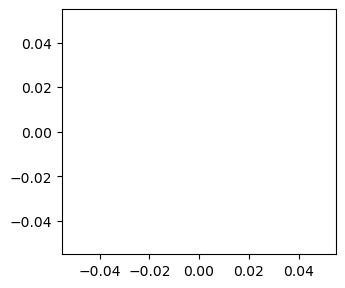

In [13]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    train_loss, val_loss, proto_loss, gate_loss, custom_loss, hier_loss  = [], [], [], [], [], []
    mean_bias, min_bias, fmax, micro_auprc, max_tau, min_tau, mean_tau, max_bias = [], [], [], [], [], [], [], []

    # 定义正则匹配模式
    train_pattern = re.compile(r"Averaged stats: lr: ([\d.eE+-]+)  loss: ([\d.eE+-]+)  temperature: ([\d.eE+-]+)")
    # val_pattern = re.compile(r"Averaged stats\(Valid\):\s+total_loss:\s+([\d.eE+-]+)\s+proto_loss:\s+([\d.eE+-]+)\s+tau_max:\s+([\d.eE+-]+)\s+tau_min:\s+([\d.eE+-]+)\s+tau_mean:\s+([\d.eE+-]+)\s+bias_max:\s+([\d.eE+-]+)\s+bias_min:\s+([\d.eE+-]+)\s+bias_mean:\s+([\d.eE+-]+),\s+Fmax:\s+([\d.eE+-]+),\s+micro AUPRC:\s+([\d.eE+-]+),\s+target frequency:\s+([\d.eE+-]+)")
    val_pattern = re.compile(r"Averaged stats: .* loss: ([\d.eE+-]+)  temperature: ([\d.eE+-]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = val_pattern.search(line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                # proto_loss.append(float(val_match.group(2)))
                # max_tau.append(float(val_match.group(3)))
                # min_tau.append(float(val_match.group(4)))
                # mean_tau.append(float(val_match.group(5)))
                # max_bias.append(float(val_match.group(6)))
                # min_bias.append(float(val_match.group(7)))
                # mean_bias.append(float(val_match.group(8)))
                # fmax.append(float(val_match.group(9)))
                # micro_auprc.append(float(val_match.group(10)))
                continue # 匹配到 Valid 后跳过，防止被下方 Train 模式二次匹配
            
            train_match = train_pattern.search(line)
            if train_match:
                train_loss.append(float(train_match.group(1)))

    # 对数化处理以更清晰地展示损失变化趋势
    eps = 1e-8
    train_loss = [np.log(x + eps) for x in train_loss]
    val_loss = [np.log(x + eps) for x in val_loss]
    # hier_loss = [np.log(x + eps) for x in hier_loss]
    # custom_loss = [np.log(x + eps) for x in custom_loss]
    # gate_loss = [np.log(x + eps) for x in gate_loss]
    proto_loss = [np.log(x + eps) for x in proto_loss]

    epochs = range(1, len(train_loss) + 1)
    # 开始绘图
    plt.figure(figsize=(12, 7))

    plt.subplot(2, 3, 1)
    plt.plot(epochs, train_loss, label='Train Total Loss', color='blue')
    plt.plot(epochs, val_loss, label='Valid Total Loss', color='red', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 3, 2)
    # plt.plot(epochs, proto_loss, label='proto_loss', color='blue')
    # plt.title('Training & Validation Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('Loss (log)')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 3, 3)
    # plt.plot(epochs, max_tau, label='max_tau', color='blue')
    # plt.plot(epochs, min_tau, label='min_tau', color='red')
    # plt.plot(epochs, mean_tau, label='mean_tau', color='green')
    # plt.title('Training & Validation Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('Loss (log)')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 3, 4)
    # plt.plot(epochs, max_bias, label='max_bias', color='blue')
    # plt.plot(epochs, min_bias, label='min_bias', color='red')
    # plt.plot(epochs, mean_bias, label='mean_bias', color='green')
    # plt.title('Training & Validation Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('Loss (log)')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 3, 5)
    # plt.plot(epochs, fmax, label='Fmax', color='green')
    # plt.plot(epochs, micro_auprc, label='micro AUPRC', color='orange')
    # plt.title('Validation Metrics')
    # plt.xlabel('Epoch')
    # plt.ylabel('Score')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_log_metrics("../../log/first.txt")
# plot_log_metrics("../../log/second.txt")
# plot_log_metrics("../../log/lr3e-4.txt")

4、一阶段日志

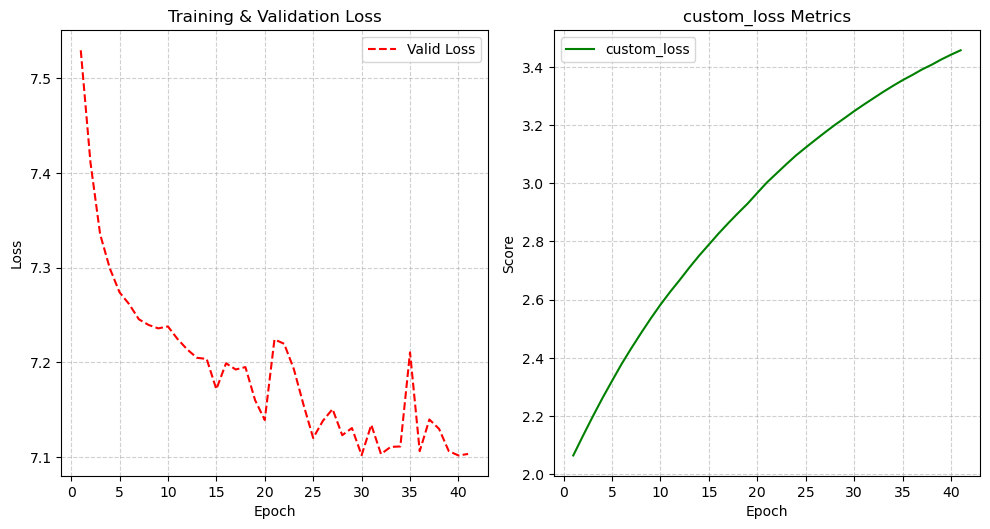

In [47]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    train_loss, val_loss = [], []
    fmax, micro_auprc, custom_loss, hier_loss = [], [], [], []

    # 定义正则匹配模式
    # train_pattern = re.compile(r"Averaged stats: lr: ([\d.]+)  total_loss: ([\d.]+)  custom_loss: ([\d.]+)  hier_loss: ([\d.]+)")
    train_pattern = re.compile(r"Averaged stats: lr: ([\d.]+)  loss: ([\d.]+)  temperature: ([\d.]+)")
    # val_pattern = re.compile(r"Averaged stats: total_loss: ([\d.]+)  custom_loss: ([\d.]+)  hier_loss: ([\d.]+)")
    val_pattern = re.compile(r"Averaged stats: loss: ([\d.]+)  temperature: ([\d.]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = val_pattern.search(line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                custom_loss.append(float(val_match.group(2)))
                # hier_loss.append(float(val_match.group(3)))
                # fmax.append(float(val_match.group(4)))
                # micro_auprc.append(float(val_match.group(5)))
                continue # 匹配到 Valid 后跳过，防止被下方 Train 模式二次匹配
            
            train_match = train_pattern.search(line)
            if train_match:
                train_loss.append(float(train_match.group(2)))

    epochs = range(1, len(train_loss) + 1)
    
    eps = 1e-8
    train_loss = [np.log(x + eps) for x in train_loss]
    val_loss = [np.log(x + eps) for x in val_loss]

    # 开始绘图
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 2, 1)
    # plt.plot(epochs, train_loss, label='Train Loss', color='blue')
    plt.plot(epochs, val_loss, label='Valid Loss', color='red', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(2, 2, 2)
    plt.plot(epochs, custom_loss, label='custom_loss', color='green')
    plt.title('custom_loss Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 2, 3)
    # plt.plot(epochs, hier_loss, label='hier_loss', color='orange')
    # plt.title('hier_loss Metrics')
    # plt.xlabel('Epoch')
    # plt.ylabel('Score')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(2, 2, 4)
    # plt.plot(epochs, fmax, label='Fmax', color='green')
    # plt.plot(epochs, micro_auprc, label='micro AUPRC', color='orange')
    # plt.title('Validation Metrics')
    # plt.xlabel('Epoch')
    # plt.ylabel('Score')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_log_metrics("../../log/third.txt")

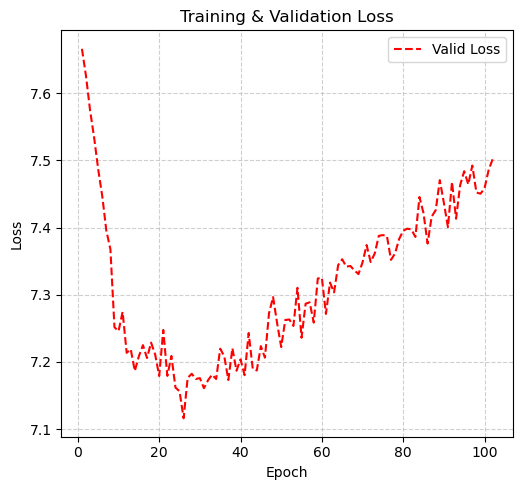

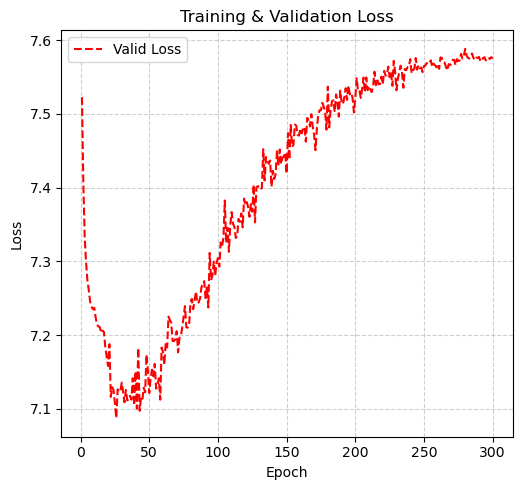

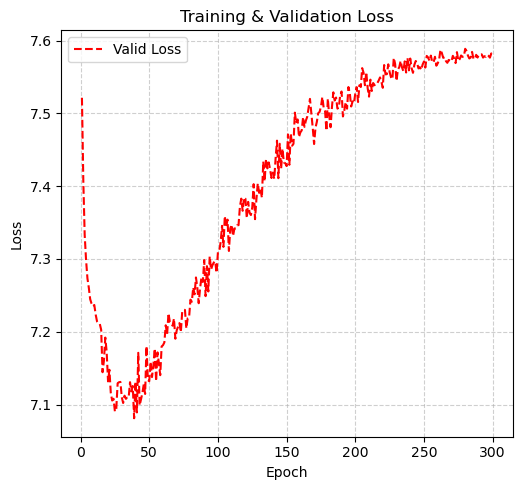

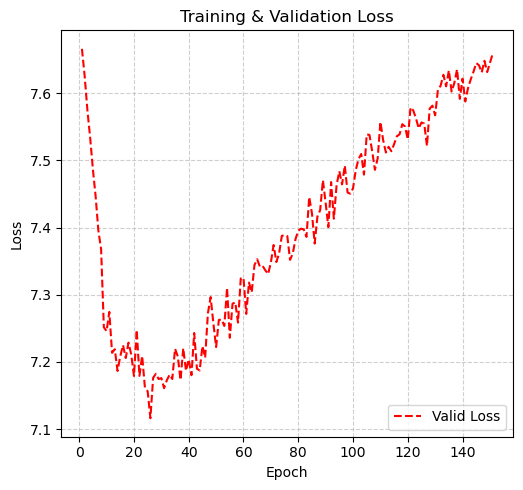

In [36]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    train_loss, val_loss = [], []
    fmax, micro_auprc = [], []

    # 定义正则匹配模式
    train_pattern = re.compile(r"Averaged stats: lr: ([\d.]+)  loss: ([\d.]+)  temperature: ([\d.]+)")
    # val_pattern = re.compile(r"Averaged stats\(Valid\): loss: ([\d.]+)  temperature: ([\d.]+), Fmax: ([\d.]+), micro AUPRC: ([\d.]+)")
    val_pattern = re.compile(r"Averaged stats: loss: ([\d.]+)  temperature: ([\d.]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = val_pattern.search(line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                # fmax.append(float(val_match.group(3)))
                # micro_auprc.append(float(val_match.group(4)))
                continue # 匹配到 Valid 后跳过，防止被下方 Train 模式二次匹配
            
            train_match = train_pattern.search(line)
            if train_match:
                train_loss.append(float(train_match.group(1)))

    epochs = range(1, len(train_loss) + 1)
    
    eps = 1e-8
    train_loss = [np.log(x + eps) for x in train_loss]
    val_loss = [np.log(x + eps) for x in val_loss]

    # 开始绘图
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    # plt.plot(epochs, train_loss, label='Train Loss', color='blue')
    plt.plot(epochs, val_loss, label='Valid Loss', color='red', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # plt.subplot(1, 2, 2)
    # plt.plot(epochs, fmax, label='Fmax', color='green')
    # plt.plot(epochs, micro_auprc, label='micro AUPRC', color='orange')
    # plt.title('Validation Metrics')
    # plt.xlabel('Epoch')
    # plt.ylabel('Score')
    # plt.legend()
    # plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_log_metrics("../../log/first.txt")
plot_log_metrics("../../log/third.txt")
plot_log_metrics("../../log/fourth.txt")
plot_log_metrics("../../log/fifth.txt")
# plot_log_metrics("../../log/first.txt")

5、为快速验证的日志文件生成对应图像(混合概率)

alpha=5, lambda=10, beta=1+


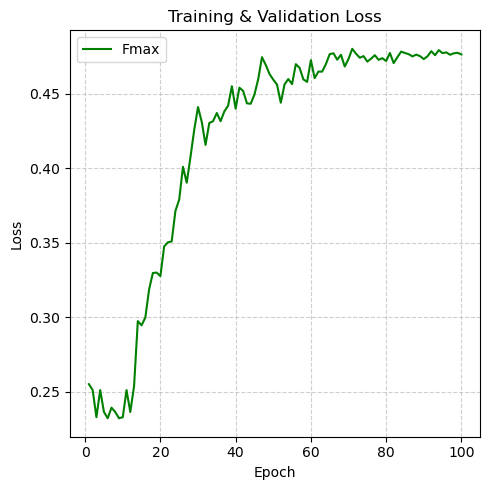

alpha=5, lambda=10, beta=2+


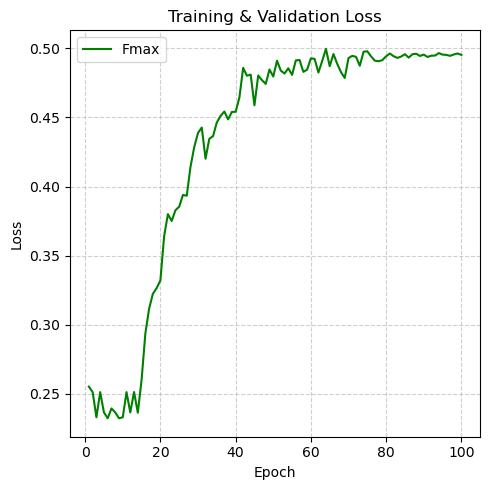

alpha=5, lambda=10, beta=3+


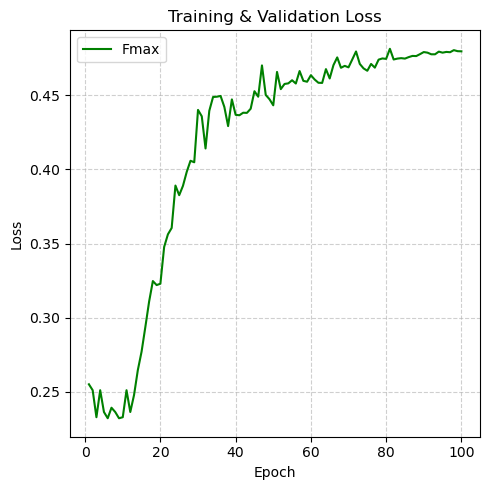

alpha=5, lambda=20, beta=1+


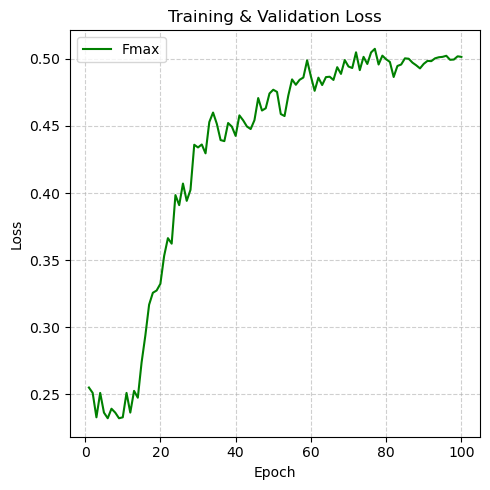

alpha=5, lambda=20, beta=2+


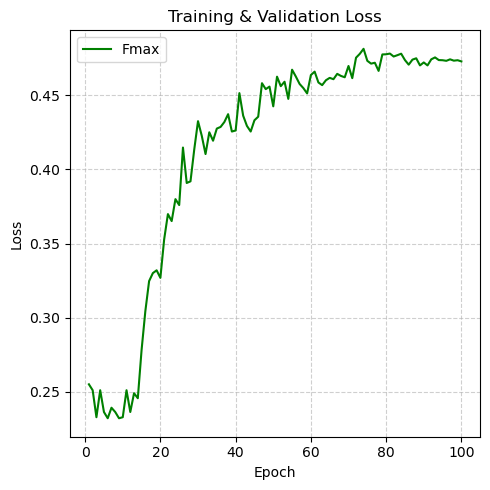

alpha=5, lambda=20, beta=3+


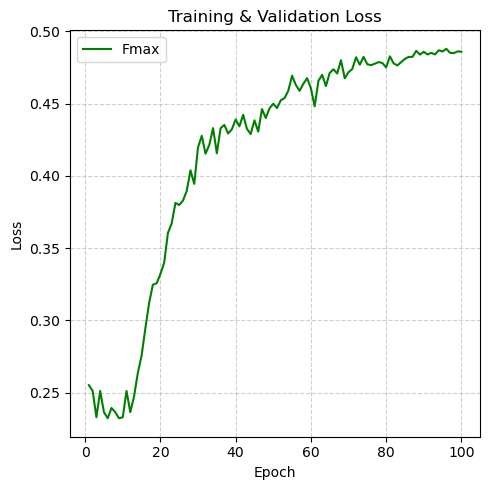

alpha=5, lambda=30, beta=1+


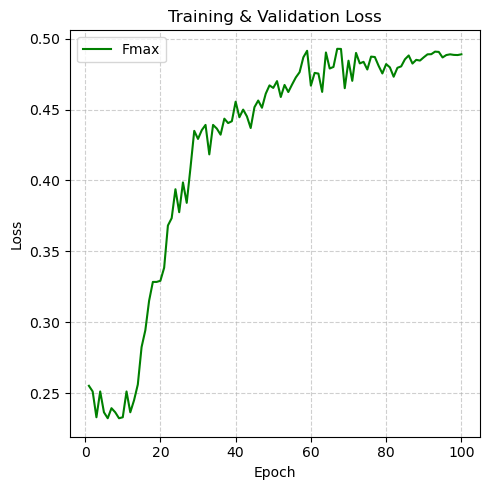

alpha=5, lambda=30, beta=2+


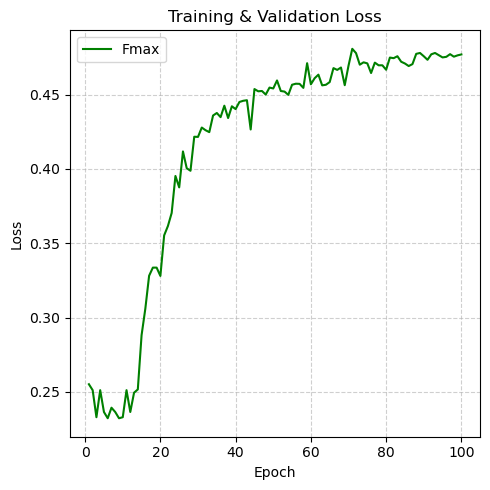

alpha=5, lambda=30, beta=3+


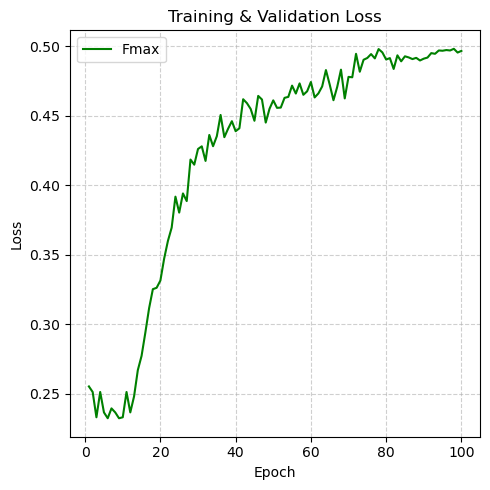

alpha=5, lambda=50, beta=1+


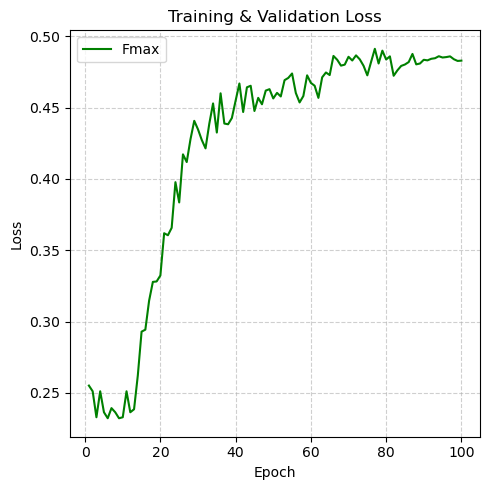

alpha=5, lambda=50, beta=2+


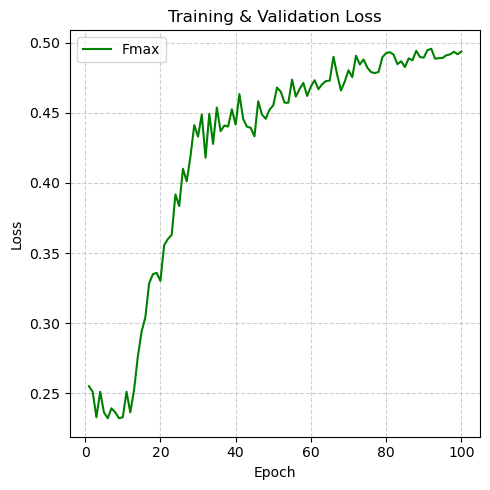

alpha=5, lambda=50, beta=3+


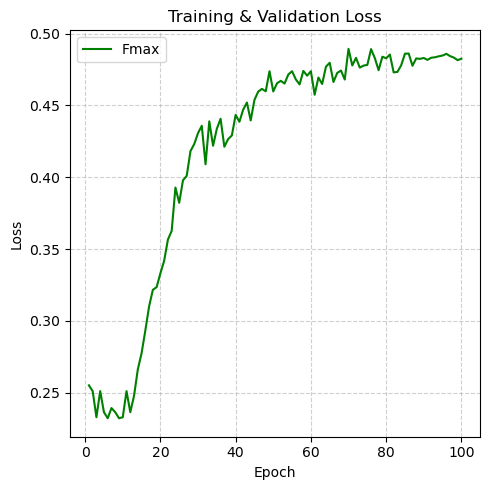

alpha=5, lambda=100, beta=1+


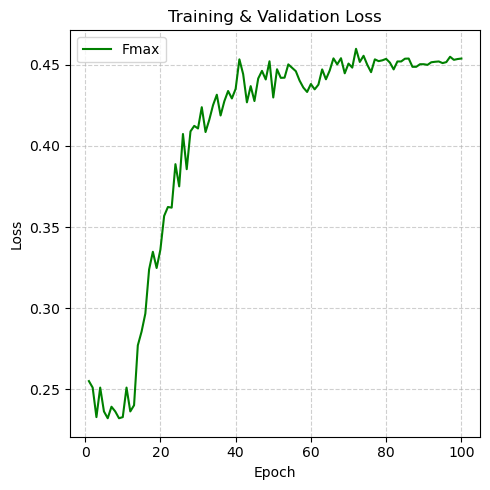

alpha=5, lambda=100, beta=2+


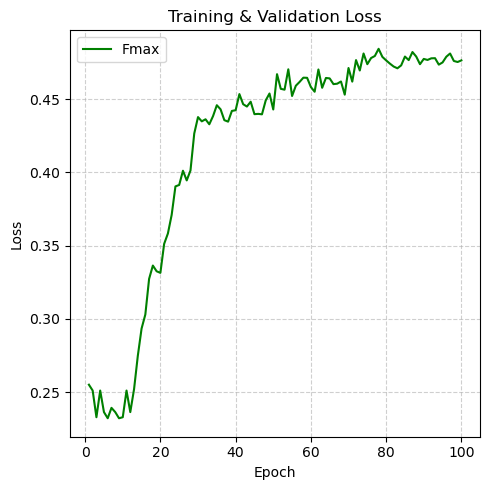

alpha=5, lambda=100, beta=3+


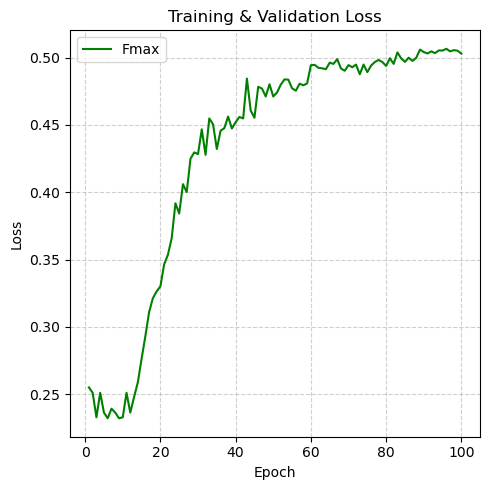

alpha=10, lambda=10, beta=1+


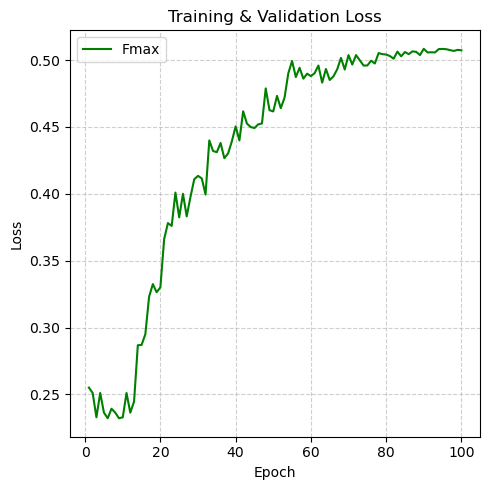

alpha=10, lambda=10, beta=2+


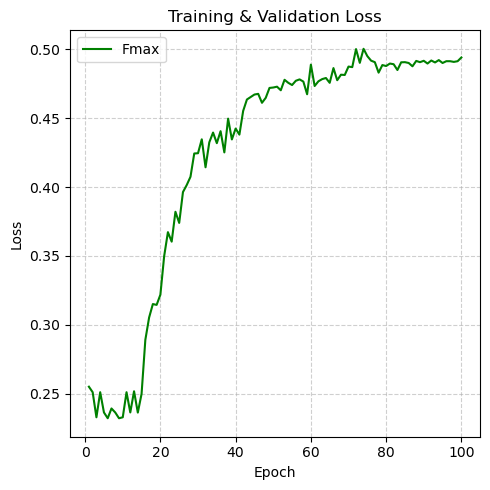

alpha=10, lambda=10, beta=3+


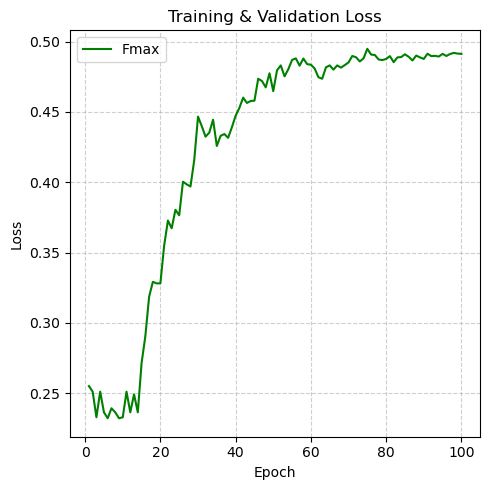

alpha=10, lambda=20, beta=1+


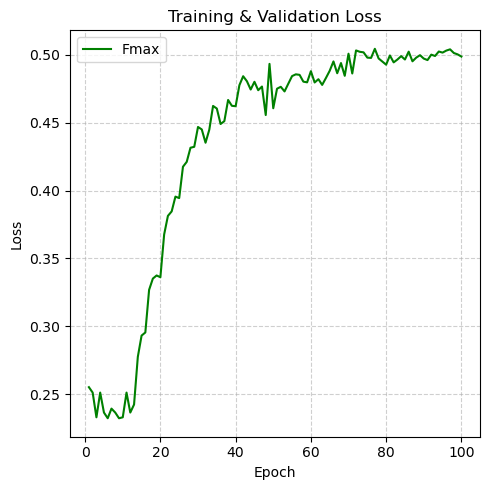

alpha=10, lambda=20, beta=2+


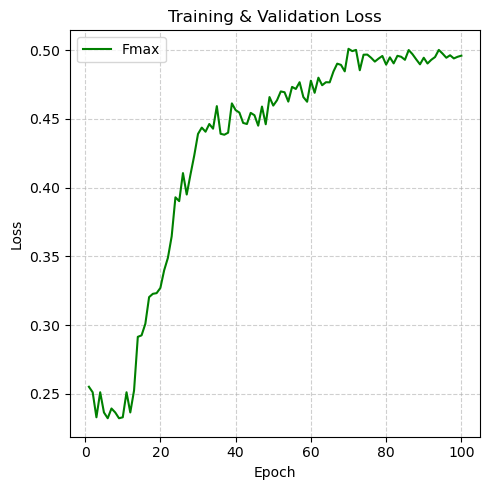

alpha=10, lambda=20, beta=3+


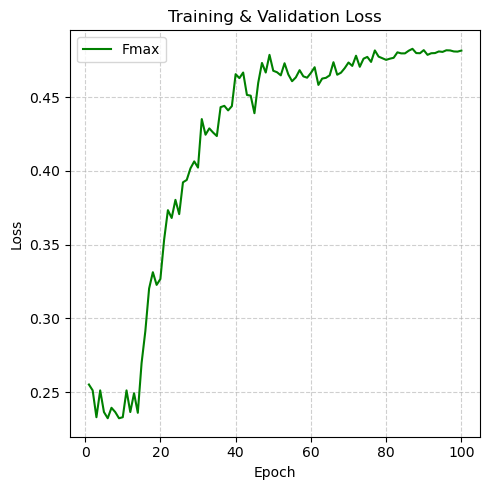

alpha=10, lambda=30, beta=1+


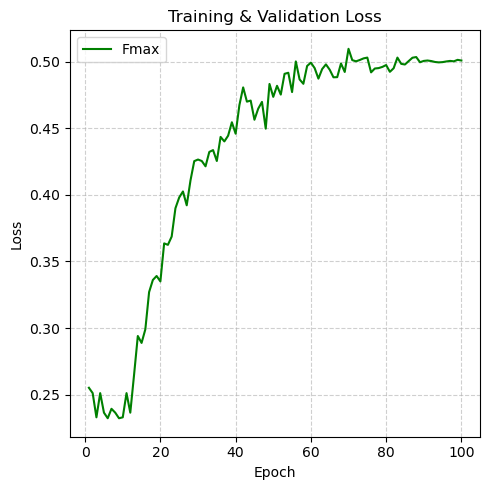

alpha=10, lambda=30, beta=2+


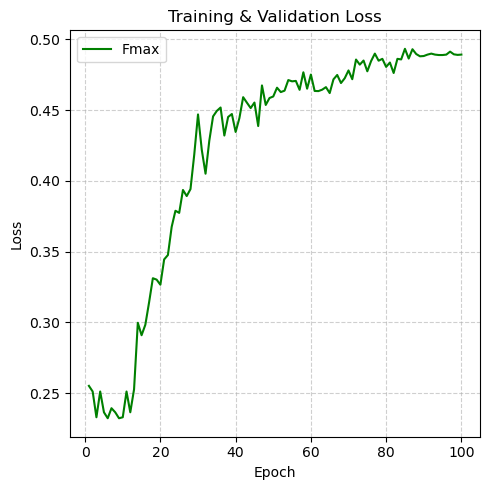

alpha=10, lambda=30, beta=3+


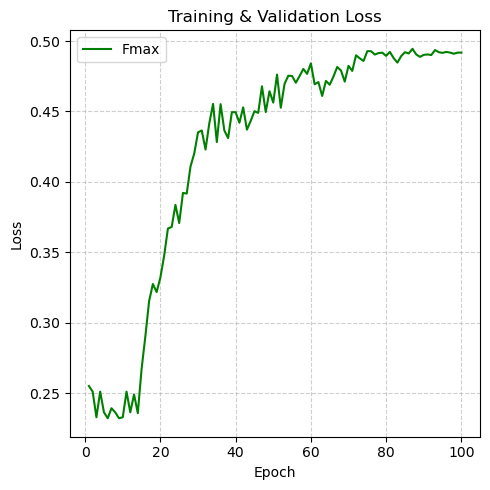

alpha=10, lambda=50, beta=1+


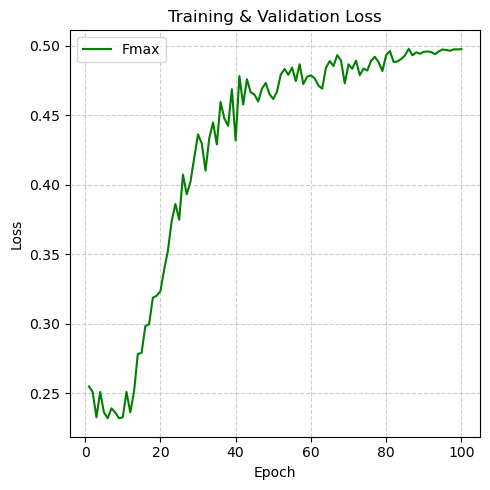

alpha=10, lambda=50, beta=2+


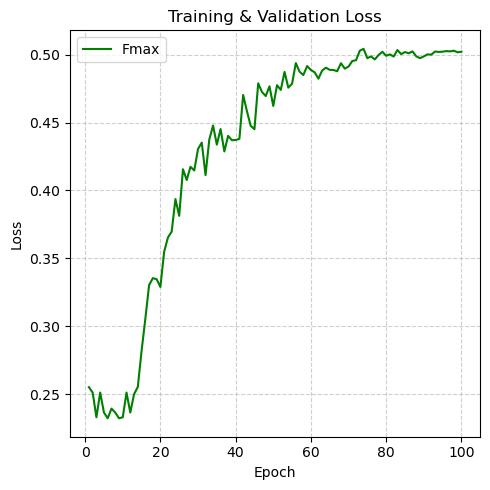

alpha=10, lambda=50, beta=3+


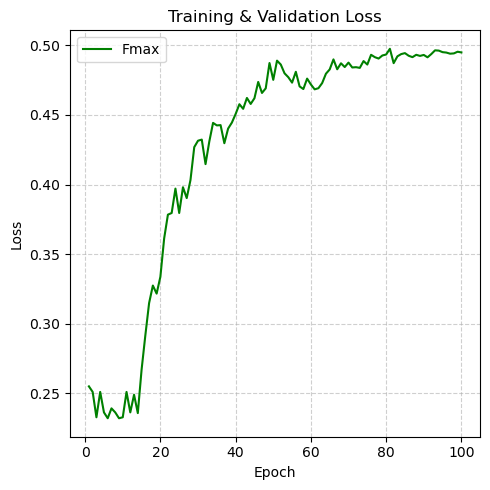

alpha=10, lambda=100, beta=1+


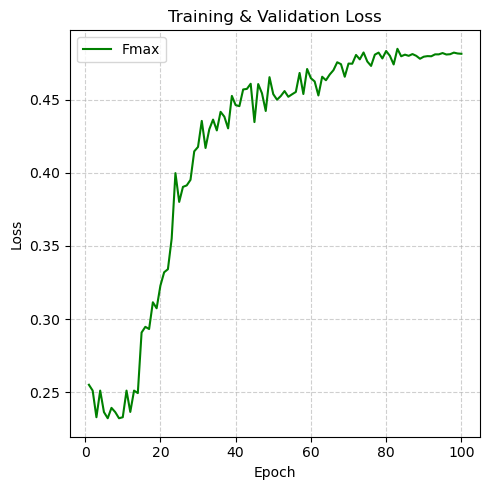

alpha=10, lambda=100, beta=2+


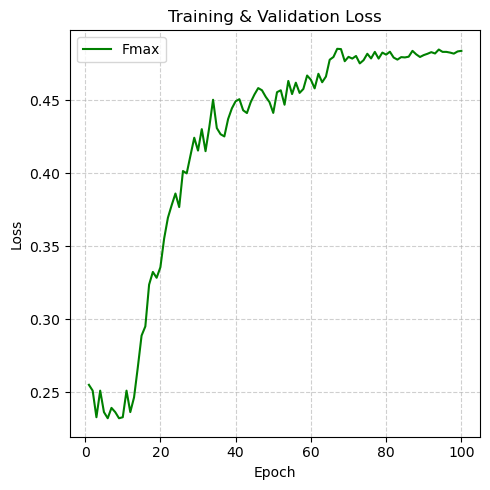

alpha=10, lambda=100, beta=3+


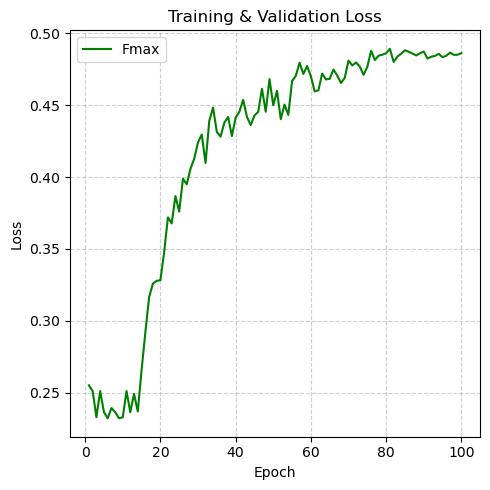

alpha=20, lambda=10, beta=1+


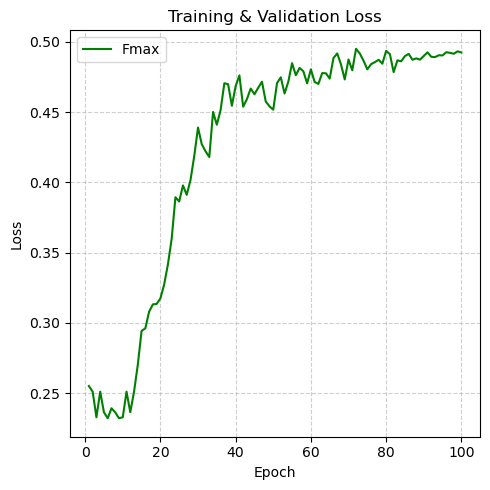

alpha=20, lambda=10, beta=2+


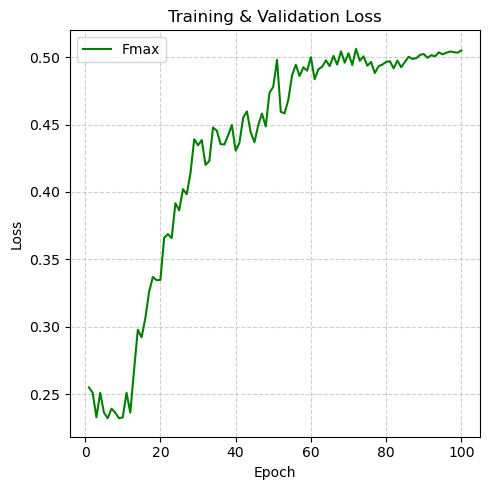

alpha=20, lambda=10, beta=3+


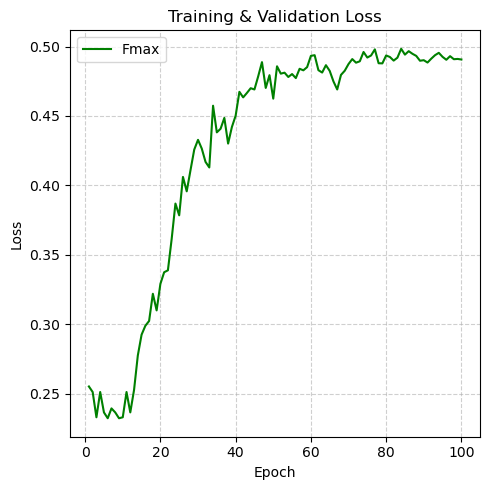

alpha=20, lambda=20, beta=1+


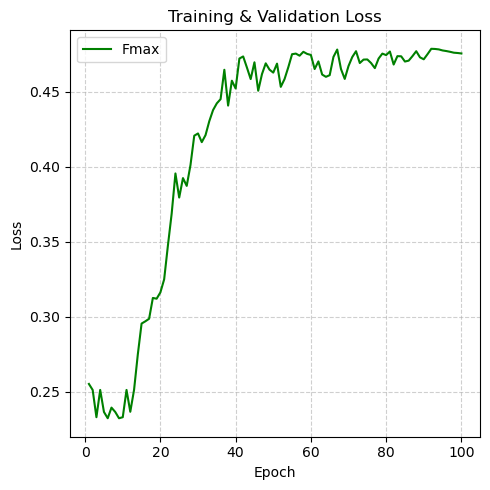

alpha=20, lambda=20, beta=2+


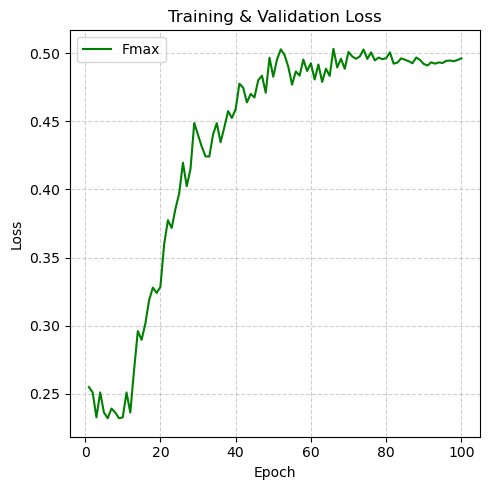

alpha=20, lambda=20, beta=3+


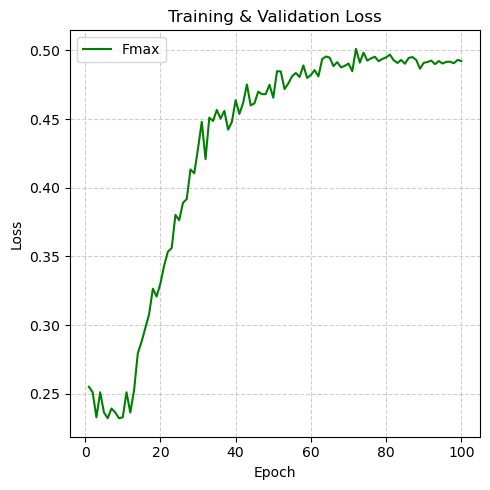

alpha=20, lambda=30, beta=1+


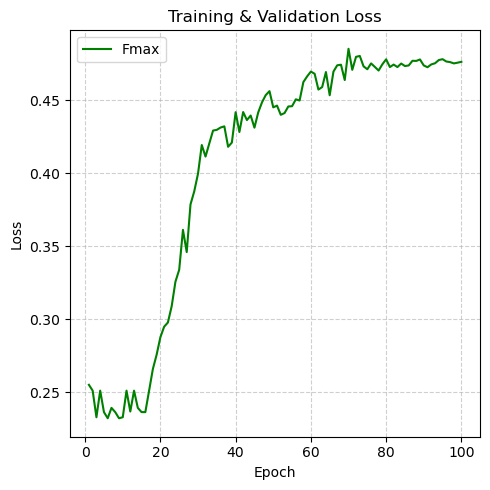

alpha=20, lambda=30, beta=2+


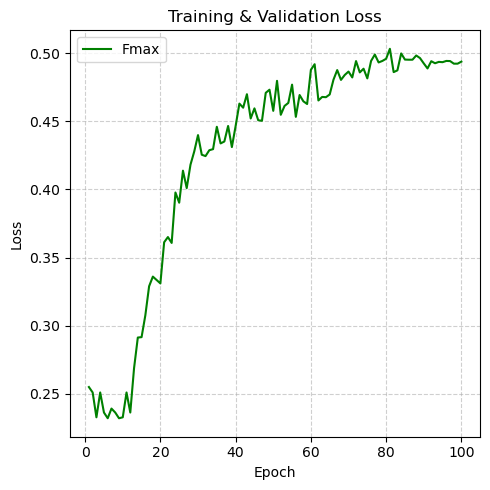

alpha=20, lambda=30, beta=3+


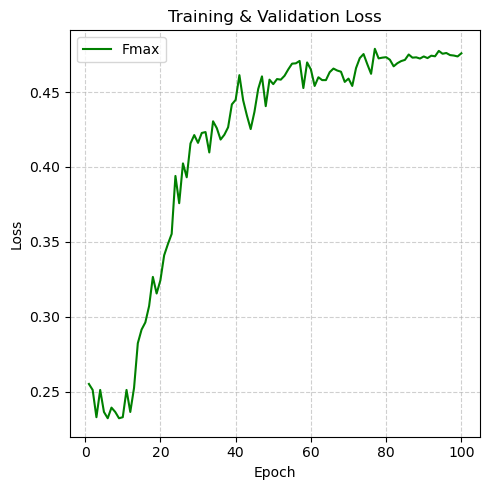

alpha=20, lambda=50, beta=1+


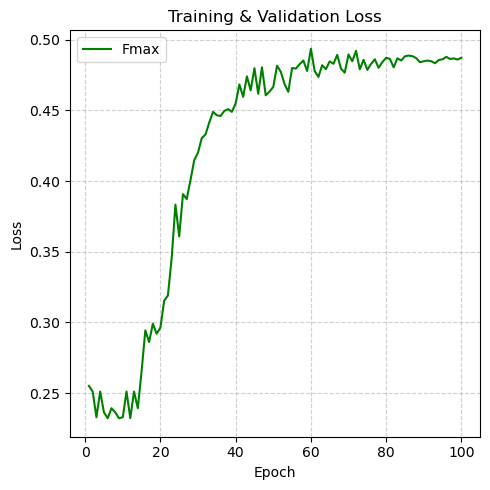

alpha=20, lambda=50, beta=2+


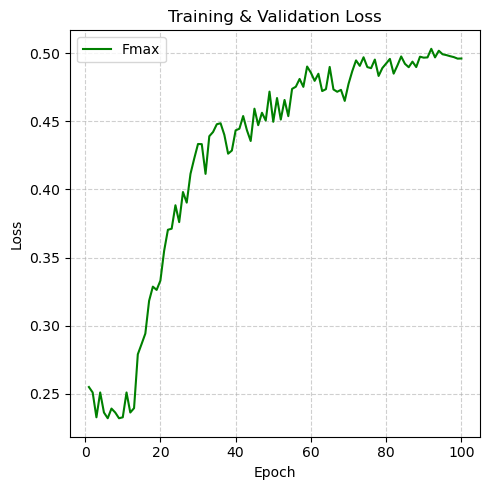

alpha=20, lambda=50, beta=3+


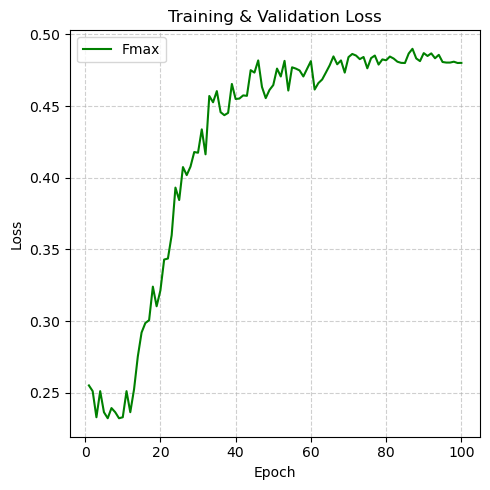

alpha=20, lambda=100, beta=1+


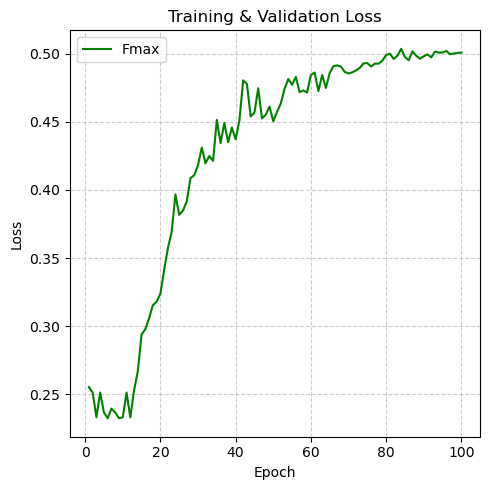

alpha=20, lambda=100, beta=2+


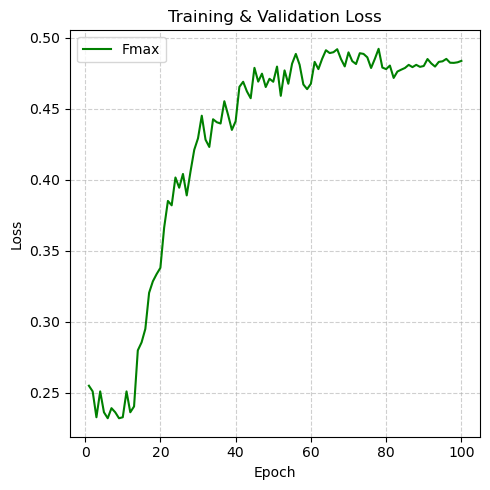

alpha=20, lambda=100, beta=3+


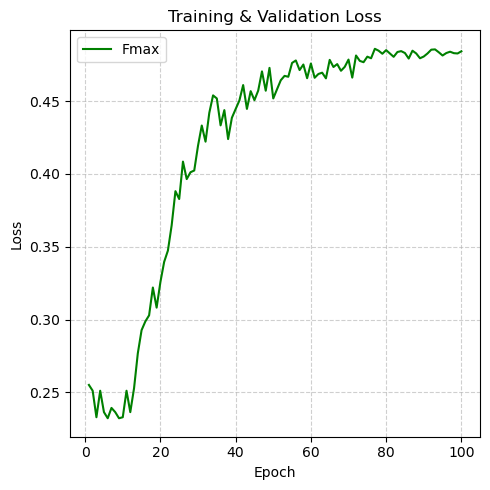

alpha=30, lambda=10, beta=1+


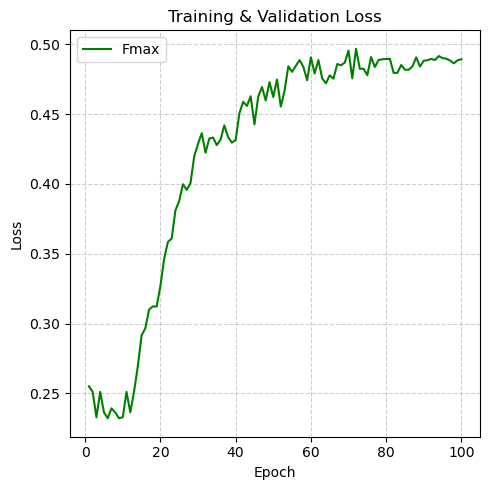

alpha=30, lambda=10, beta=2+


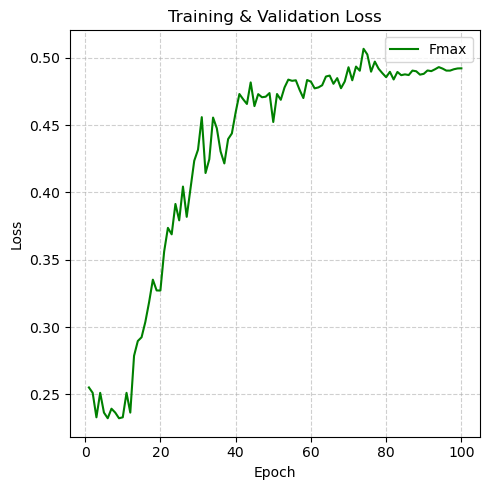

alpha=30, lambda=10, beta=3+


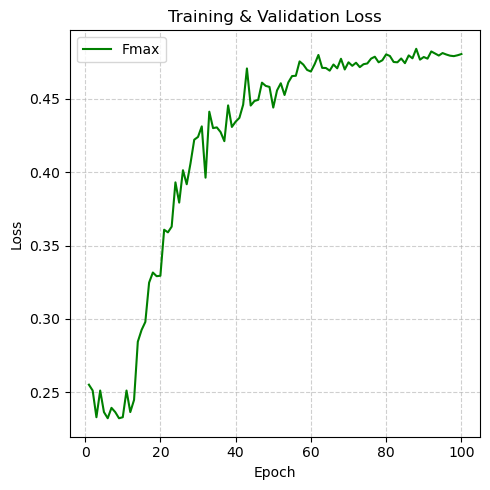

alpha=30, lambda=20, beta=1+


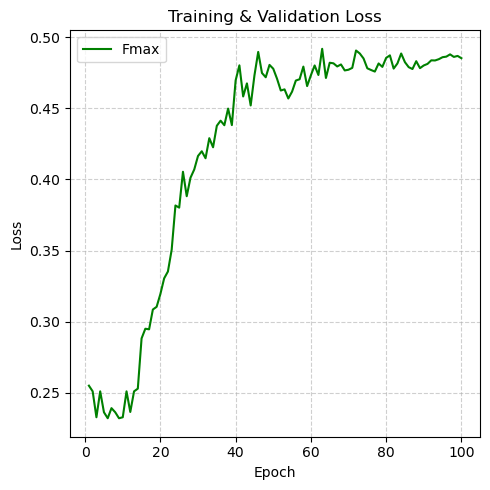

alpha=30, lambda=20, beta=2+


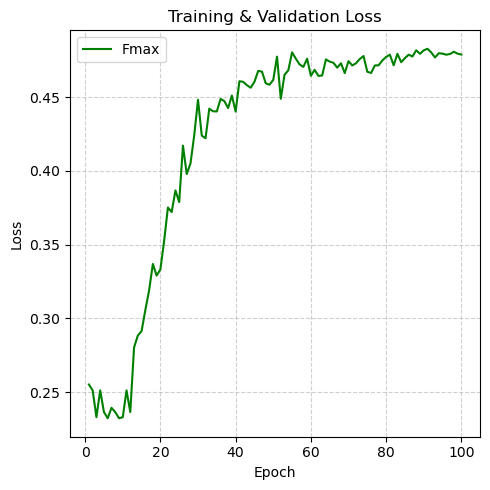

alpha=30, lambda=20, beta=3+


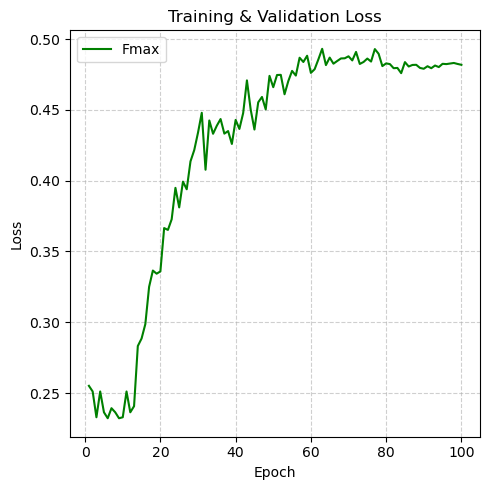

alpha=30, lambda=30, beta=1+


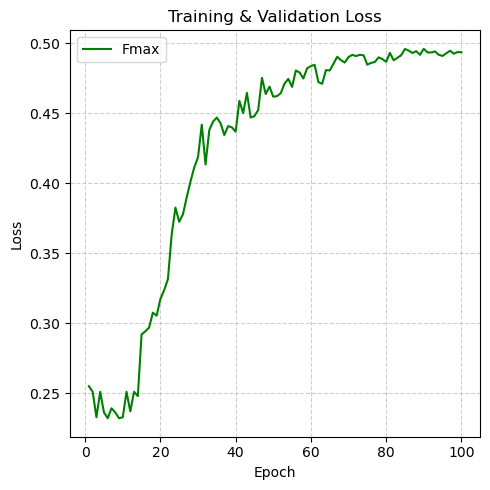

alpha=30, lambda=30, beta=2+


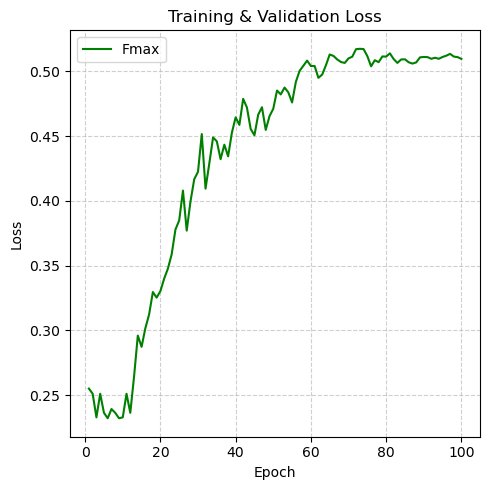

alpha=30, lambda=30, beta=3+


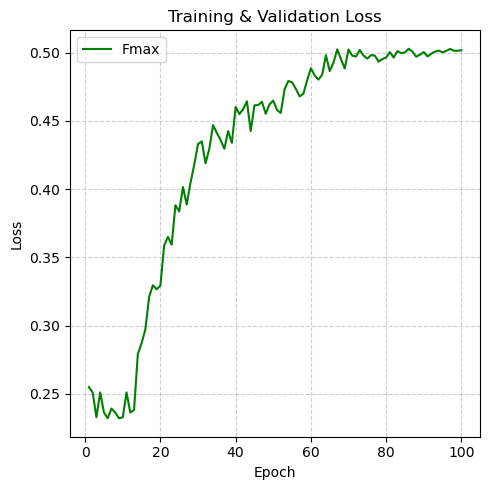

alpha=30, lambda=50, beta=1+


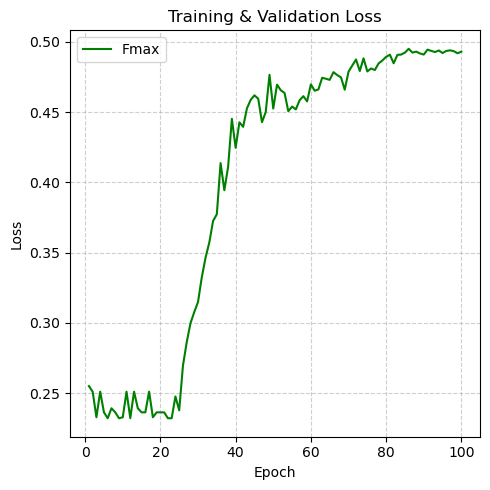

alpha=30, lambda=50, beta=2+


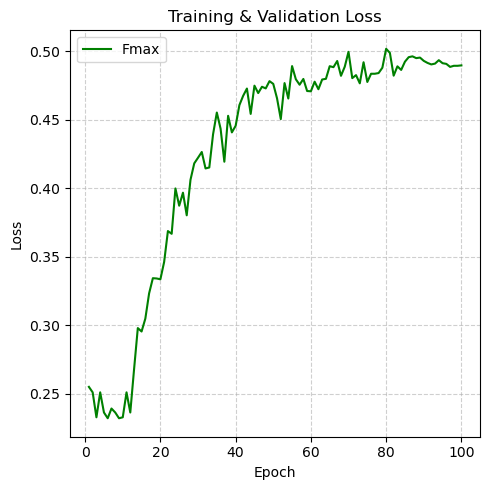

alpha=30, lambda=50, beta=3+


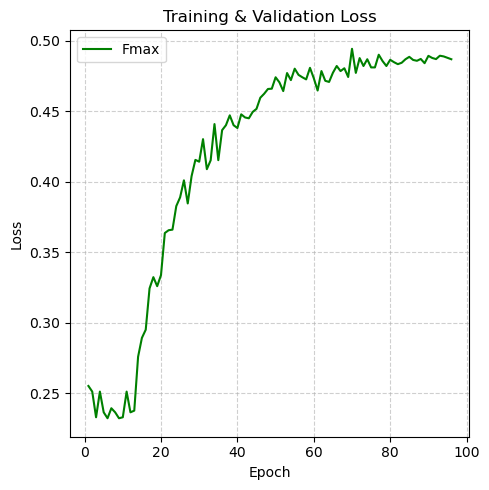

alpha=30, lambda=100, beta=1+


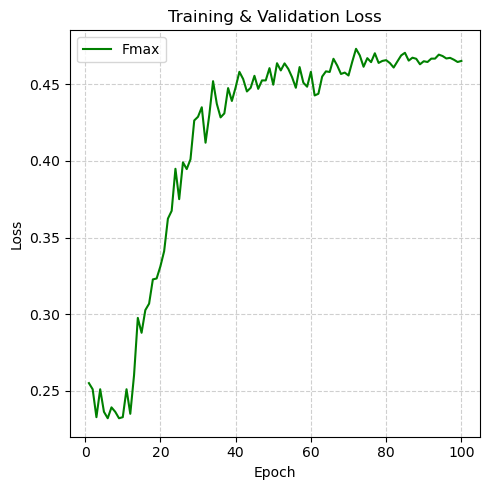

alpha=30, lambda=100, beta=2+


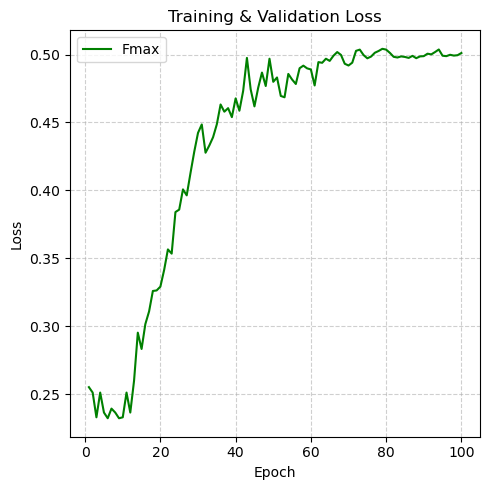

alpha=30, lambda=100, beta=3+


FileNotFoundError: [Errno 2] No such file or directory: '../../log/train_alpha_30_lambda_100_beta_3+.txt'

In [ ]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    Fmax, val_loss = [], []

    # 定义正则匹配模式
    pattern = re.compile(r"  ALF \[0, 0.2\]: n=59, Fmax=([\d.]+), micro_AUPRC=([\d.]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = pattern.search(line)
            if val_match:
                Fmax.append(float(val_match.group(1)))

    epochs = range(1, len(Fmax) + 1)

    # 开始绘图
    plt.figure(figsize=(5, 5))
    plt.subplot(1, 1, 1)
    # plt.plot(epochs, train_loss, label='Train Loss', color='blue')
    plt.plot(epochs, Fmax, label='Fmax', color='green')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

alphas=[5, 10, 20, 30, 50]
lambdas=[10, 20, 30, 50, 100]
betas=['3+']
for alpha in alphas:
    for lambda_ in lambdas:
        for beta in betas:
            log_file_path = f"../../log/train_alpha_{alpha}_lambda_{lambda_}_beta_{beta}.txt"
            print(f"alpha={alpha}, lambda={lambda_}, beta={beta}")
            plot_log_metrics(log_file_path)


6、为每种go term计算原型。顺序为go term id的顺序

In [2]:
import pickle
import torch

def get_prototypes(labels_path, features_path):
    # 1. 加载数据与特征
    with open(labels_path, 'rb') as f:
        labels_list = pickle.load(f)
    features = torch.load(features_path, map_location='cpu')

    # 若特征为 list 则转换为 2D Tensor
    if isinstance(features, list):
        features = torch.stack(features)

    # 2. 将多标签映射关系扁平化为 1D 索引, protein_indices为蛋白质的索引，go_indices为对应的GO term索引，假设index为n，则protein_indices[n]注释的功能为go_indices[n]
    protein_indices = [i for i, labels in enumerate(labels_list) for _ in labels]
    go_indices = [label for labels in labels_list for label in labels]

    # 3. 转移到 GPU/CPU 进行快速原型计算
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    p_idx = torch.tensor(protein_indices, dtype=torch.long, device=device)
    go_idx = torch.tensor(go_indices, dtype=torch.long, device=device)
    features = torch.stack([f for f in features.values()]).to(device)

    # 初始化目标原型矩阵 (M, D)，利用内置的 index_reduce_ 一步完成均值计算
    num_classes = go_idx.max().item() + 1
    prototypes = torch.zeros((num_classes, features.shape[1]), dtype=features.dtype, device=device)
    prototypes.index_reduce_(0, go_idx, features[p_idx], reduce='mean', include_self=False)

    return prototypes.cpu()

# 4. 保存按 GO term ID 排序的原型特征
prototypes = get_prototypes('./data_tale/CAFA3/test_label_cc', '/archive/hot5/fty/protein_feats/train_cc_protein_feats.pt')
torch.save(prototypes, '/archive/hot5/fty/prototypes_feats/train_prototypes.pt')

/tmp/ipykernel_102485/3000893126.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(features_path, map_location='cpu')


KeyboardInterrupt: 

7、打印测试集/验证集频率排序

In [17]:
def invert_dict(original: dict) -> dict:

    reversed_dict = {}
    for key, val in original.items():
        reversed_dict.setdefault(val, []).append(key)
    # 按键排序后返回新字典（Python 3.7+ 会保持插入顺序）
    return {k: reversed_dict[k] for k in sorted(reversed_dict)}


class_name = 'CC'
test_frequency = utils.count_occurrences('./data/'+class_name+'/evaluate_gene_label', './data/'+class_name+'/term_list')
eval_frequency = utils.count_occurrences('./data/'+class_name+'/test_gene_label', './data/'+class_name+'/term_list')

test_f = invert_dict(test_frequency)
valid_f = invert_dict(eval_frequency)


NameError: name 'utils' is not defined

8、为go term生成初始PubMedBert嵌入

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
from goatools.obo_parser import GODag
import csv
import re
import sys

def get_embedding(sentences):
    """
    # Sentences we want sentence embeddings for
    sentences = ['This is an example sentence', 'Each sentence is converted']
    """
    # Mean Pooling - Take attention mask into account for correct averaging
    def meanpooling(output, mask):
        embeddings = output[0] # First element of model_output contains all token embeddings
        mask = mask.unsqueeze(-1).expand(embeddings.size()).float()
        return torch.sum(embeddings * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)

    # Load model from HuggingFace Hub
    tokenizer = AutoTokenizer.from_pretrained("neuml/pubmedbert-base-embeddings")
    model = AutoModel.from_pretrained("neuml/pubmedbert-base-embeddings", device_map="cuda:5")

    # Tokenize sentences
    inputs = tokenizer(sentences, padding=True, truncation=False, return_tensors='pt').to(model.device)
    print(inputs['input_ids'].shape)

    # Compute token embeddings
    with torch.no_grad():
        output = model(**inputs)

    # Perform pooling. In this case, mean pooling.
    embeddings = meanpooling(output, inputs['attention_mask'])

    return embeddings # shape(sentences_num, 768)

def construct_input(go_ids, obo_path="./data_tale/TALE/go-basic.obo"):

    godag = GODag(obo_path, optional_attrs={'defn'})
    inputs = []
    for go_id in go_ids:
        go_term = godag[go_id]

        name = go_term.name
        desc = re.search(r'"([^"]*)"', go_term.defn).group(1)
        inputs.append(f"GO Name: {name}. GO Description: {desc}")

    return inputs

def split_into_num(lst, num=40):
    
    n = len(lst)
    size, rem = divmod(n, num)          # 基础长度和余数
    it = iter(lst)
    return [ [next(it) for _ in range(size + (i < rem))] for i in range(num) ]

def read_txt_to_list(file_path):
    go_ids = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f, start=1):
            if idx==1: continue
            line = line.strip()
            if not line:          # 跳过空行
                continue
            # 按逗号分割，最多分成两部分
            go = line.split(',', 1)[1]
            go_ids.append(go)

    return go_ids

with open('./data_tale/TALE/cc_go_1.pickle', 'rb') as f:
    gos = pickle.load(f)

inputs = construct_input([go for go in gos.keys()])
embeddings = torch.cat([get_embedding(lst) for lst in split_into_num(inputs)], dim=0) # 将数据拆分成n份，一次会爆内存。
print(embeddings.shape)
torch.save(embeddings, './data_tale/TALE/cc_go_feats.pt')

./data_tale/TALE/go-basic.obo: fmt(1.2) rel(2020-12-08) 47,295 Terms; optional_attrs(def)
torch.Size([65, 185])
torch.Size([65, 161])
torch.Size([65, 127])
torch.Size([65, 168])
torch.Size([65, 219])
torch.Size([65, 183])
torch.Size([65, 142])
torch.Size([65, 152])
torch.Size([65, 135])
torch.Size([65, 208])
torch.Size([65, 194])
torch.Size([65, 126])
torch.Size([65, 118])
torch.Size([65, 195])
torch.Size([64, 121])
torch.Size([64, 127])
torch.Size([64, 122])
torch.Size([64, 137])
torch.Size([64, 134])
torch.Size([64, 231])
torch.Size([64, 112])
torch.Size([64, 112])
torch.Size([64, 99])
torch.Size([64, 129])
torch.Size([64, 129])
torch.Size([64, 168])
torch.Size([64, 195])
torch.Size([64, 127])
torch.Size([64, 147])
torch.Size([64, 210])
torch.Size([64, 160])
torch.Size([64, 157])
torch.Size([64, 136])
torch.Size([64, 197])
torch.Size([64, 130])
torch.Size([64, 97])
torch.Size([64, 156])
torch.Size([64, 120])
torch.Size([64, 127])
torch.Size([64, 134])
torch.Size([2574, 768])


: 

9、为蛋白质生成ESM2嵌入并保存

In [ ]:
import pickle
import torch
import esm
from tqdm import tqdm

def intference_features(seq_file, is_pool=False):

    with open(seq_file, 'rb') as f:
        data = pickle.load(f)

    # 按原始索引编号 (key=int, 保持源文件顺序)
    sequences = [(i, item['seq']) for i, item in enumerate(data)]

    # 加载 ESM-2 轻量模型
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()	
    model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
    model = model.to(device).eval()
    batch_converter = alphabet.get_batch_converter()

    # 按长度排序分批推理 (减少 padding 浪费)
    sorted_indices = sorted(range(len(sequences)), key=lambda i: len(sequences[i][1]))
    batch_size = 32
    feats_dict = {}  # {idx: tensor}

    desc = 'Extracting pooled features' if is_pool else 'Extracting residue features'
    for start in tqdm(range(0, len(sorted_indices), batch_size), desc=desc):
        batch_idx = sorted_indices[start : start + batch_size]
        batch_data = [sequences[i] for i in batch_idx]

        _, _, batch_tokens = batch_converter(batch_data)
        batch_tokens = batch_tokens.to(device)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[30], return_contacts=False)

        token_repr = results['representations'][30]

        for k, idx in enumerate(batch_idx):
            mask = batch_tokens[k] != alphabet.padding_idx
            valid_len = mask.sum().item()
            if is_pool:
                # 平均池化：对有效残基取均值，得到蛋白质级特征
                feats = token_repr[k, 1 : valid_len - 1].mean(dim=0).float().cpu()
            else:
                # 取残基级特征: 去掉 BOS/EOS, 只保留有效残基
                feats = token_repr[k, 1 : valid_len - 1].cpu()
            feats_dict[idx] = feats

    return feats_dict # 字典的key是train_seqq_cc的索引,value是改蛋白质对应的特征


# =============================================
seq_file = './data_tale/CAFA3/train_seq_cc'
save_path = '/archive/hot5/fty/protein_feats/train_cc_protein_feats.pt'
is_pool = True  # True 表示提取蛋白质级特征，False 表示提取残基级特征

feats = intference_features(seq_file, is_pool=is_pool)
print([feats[i] for i in range(10)])
torch.save(feats, save_path)
print(f'Done. Saved {len(feats)} proteins.')

Extracting pooled features: 100%|██████████| 1582/1582 [15:26<00:00,  1.71it/s]


[tensor([-1.3100e-01,  7.3795e-02,  4.3692e-02, -1.2503e-01, -1.0957e-01,
        -9.5289e-02, -9.4851e-02, -7.7788e-02, -7.9551e-02,  1.2717e-01,
         6.8911e-02,  1.2199e-01, -2.0396e-02,  1.1761e-01,  1.3242e-01,
        -4.3742e-02, -1.0300e-01, -7.7848e-02, -7.8521e-02, -8.1749e-02,
         6.2540e-02, -6.0603e-02,  1.2313e-02,  2.3781e-02, -4.1153e-02,
         3.8478e-02,  8.0644e-02, -1.7758e-02,  1.1962e-01,  5.2400e-02,
         9.0052e-03, -1.0354e-01, -9.3172e-03, -1.0278e-03, -9.5392e-02,
         9.7928e-02,  4.0924e-02,  8.8345e-02, -1.8098e-04,  4.7085e-02,
         1.0562e-02,  2.8385e-02,  3.4287e-02, -2.0663e-02, -4.5455e-02,
        -6.5616e-02, -1.5210e-03,  2.0485e-02,  4.8357e-02, -8.7904e-03,
        -3.4071e-02,  4.2616e-02,  2.1055e-02, -5.3552e-02, -4.8422e-02,
        -1.7156e-02, -1.8039e-02,  1.5826e-02, -2.3793e-02,  6.5389e-02,
         4.4131e-02, -4.1156e-02, -3.3150e-02,  9.0995e-02, -1.3271e-01,
         7.7044e-02, -5.4805e-02,  8.8658e-02,  6.

: 

In [2]:
import torch
import esm
import pickle

seq_file = './data_tale/CAFA3/test_seq_cc'
with open(seq_file, 'rb') as f:
    data = pickle.load(f)[:10]

# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results

batch_labels, batch_strs, batch_tokens = batch_converter([(i, data[i]['seq']) for i in range(10)])
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

# Extract per-residue representations (on CPU)
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)
token_representations = results["representations"][33]

# ----------------- 修改部分 -----------------
# 针对每条序列，切片去除 BOS (索引 0) 和 EOS (索引 batch_lens[i] - 1)
res = []
for i in range(len(token_representations)):
    valid_len = batch_lens[i].item()
    # 1:valid_len - 1 只保留中间真实的氨基酸残基特征
    residue_feat = token_representations[i, 1 : valid_len - 1]
    res.append(residue_feat)
# --------------------------------------------

# Generate per-sequence representations via averaging
# NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.
print([res[i] for i in range(10)])

[tensor([[ 0.0147, -0.1286,  0.1372,  ...,  0.0691, -0.2424, -0.0909],
        [-0.0825,  0.1511,  0.2341,  ...,  0.1382,  0.1001, -0.1105],
        [ 0.1318,  0.2081,  0.0600,  ...,  0.0203, -0.1471, -0.0073],
        ...,
        [-0.0631,  0.0420, -0.1288,  ...,  0.0411, -0.0991,  0.0073],
        [-0.0163, -0.0888, -0.1247,  ...,  0.1114, -0.1316,  0.0552],
        [ 0.0569, -0.0808,  0.0654,  ...,  0.2266, -0.1919, -0.0408]]), tensor([[ 0.1941, -0.0277,  0.0258,  ..., -0.1439,  0.0062,  0.0922],
        [ 0.2276,  0.1522,  0.0449,  ..., -0.0582, -0.1089,  0.1785],
        [ 0.2383,  0.2104,  0.0303,  ..., -0.2198,  0.2796,  0.1512],
        ...,
        [-0.0030, -0.0834,  0.3088,  ...,  0.1011,  0.1811,  0.1677],
        [-0.1035, -0.0483, -0.0168,  ...,  0.1248,  0.0174,  0.0591],
        [ 0.0279, -0.1380,  0.0129,  ...,  0.0044,  0.1756, -0.0061]]), tensor([[ 0.0300,  0.1028,  0.0318,  ...,  0.1141,  0.0407,  0.2047],
        [-0.2284,  0.3599, -0.0184,  ..., -0.0042,  0.1002,

10、根据obo文件，生成拓扑关系图，并以pkl文件保存。并将图节点id保存。
此时pkl中保存的是字符串GO：XXXXX

In [16]:
import pickle
from goatools.obo_parser import GODag

def generate_go_topology(obo_path, pkl_output_path):
    """
    解析 go-basic.obo 文件，提取指定的拓扑关系并保存为 pkl。
    """
    # 1. 加载 OBO 文件
    godag = GODag(obo_path, optional_attrs=['relationship'])

    # 2. 初始化结果结构
    topology = {
        "is_a": {"head": [], "tail": []},
        "part_of": {"head": [], "tail": []},
        "positively_regulates": {"head": [], "tail": []},
        "negatively_regulates": {"head": [], "tail": []}
    }

    # 3. 提取所有非废弃的 GO ID 并排序
    all_go_ids = sorted([str(go_id) for go_id, term in godag.items() if not term.is_obsolete])

    # 4. 遍历每个 Term 提取关系
    for go_id in all_go_ids:
        term = godag[go_id]

        # 辅助函数：确保获取的是字符串 ID 而不是对象
        def get_id(obj):
            return str(obj.id) if hasattr(obj, 'id') else str(obj)

        # 处理 is_a 关系
        for parent in term.parents:
            p_id = get_id(parent)
            if p_id in godag:
                topology["is_a"]["head"].append(go_id)
                topology["is_a"]["tail"].append(p_id)

        # 处理其他关系
        if hasattr(term, 'relationship') and term.relationship:
            for rel_type, targets in term.relationship.items():
                if rel_type in topology:
                    for target in targets:
                        t_id = get_id(target)
                        if t_id in godag:
                            topology[rel_type]["head"].append(go_id)
                            topology[rel_type]["tail"].append(t_id)

    # 5. 保存为 pkl 文件 (此时 topology 内部全是字符串，不会触发递归错误)
    with open(pkl_output_path, 'wb') as f:
        pickle.dump(topology, f, protocol=pickle.HIGHEST_PROTOCOL)

    return all_go_ids

# 使用示例
if __name__ == "__main__":
    obo_file = "./data/go-basic.obo"  # 你的文件路径
    pkl_file = "./data/go_topology.pkl"
    go_id_path = "./data/graph_node_id.txt"
    
    sorted_ids = generate_go_topology(obo_file, pkl_file)
    
    with open(go_id_path, 'w', encoding='utf-8') as f:
        # 写入表头
        f.write("id,go term\n")
        # 遍历列表，写入索引和元素
        for idx, item in enumerate(sorted_ids):
            f.write(f"{idx},{item}\n")

    print(f"处理完成！共有 {len(sorted_ids)} 个 Term。")
    print(f"拓扑文件已保存至: {pkl_file}")

./data/go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms; optional_attrs(relationship)
处理完成！共有 45667 个 Term。
拓扑文件已保存至: ./data/go_topology.pkl


11、根据10生成的id，生成图节点go term的namespace文件。用于可视化验证。

In [11]:
from goatools.obo_parser import GODag

def map_go_namespace(input_txt, obo_path, output_txt):
    """
    读取input_txt中第二列的GO term，从obo中查询namespace并保存
    """
    # 加载OBO文件（预加载提高查询效率）
    godag = GODag(obo_path, load_obsolete=True)

    with open(input_txt, 'r', encoding='utf-8') as f_in, \
         open(output_txt, 'w', encoding='utf-8') as f_out:
        
        f_out.write("go term,namespace\n")
        
        for line in f_in:
            parts = line.strip().split(',')
            if len(parts) < 2:
                continue
            
            go_id = parts[1].strip()
            
            # 在GODag中匹配并获取namespace
            if go_id in godag:
                namespace = godag[go_id].namespace
                f_out.write(f"{go_id},{namespace}\n")

# 使用示例
map_go_namespace("./data/graph_node_id.txt", "./data/go-basic.obo", "./data/graph_node_namespace.txt")

./data/go-basic.obo: fmt(1.2) rel(2024-04-24) 51,471 Terms


12、将10生成的pkl文件的go term替换为id，并增加反向关系。保存到新的pkl文件中

In [ ]:
import pickle

def process_go_data(pkl_path, txt_path, output_path=None):
    # 1. 读取txt映射文件，构建 {str_id: int_id} 字典
    mapping = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            if "id" in line: continue # 过滤表头
            if line.strip():
                int_id, str_id = line.strip().split(',')
                mapping[str_id] = int(int_id)

    # 2. 读取pkl文件
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    processed_data = {}

    # 3. 转换ID并添加反向关系
    for rel, content in data.items():
        # 将原始字符串列表转换为int列表
        heads = [mapping[h] for h in content['head']]
        tails = [mapping[t] for t in content['tail']]
        
        # 存储转换后的正向关系
        processed_data[rel] = {"head": heads, "tail": tails}
        
        # 添加反向关系：head和tail对调
        processed_data[f"{rel}_reverse"] = {"head": tails, "tail": heads}

    # 4. 如果指定了输出路径则保存，否则返回对象
    if output_path:
        with open(output_path, 'wb') as f:
            pickle.dump(processed_data, f)
    
    return processed_data

# 使用示例
result = process_go_data("./data/go_topology.pkl", "./data/graph_node_id.txt", "./data/go_topology_new.pkl")

13、打印pkl文件构成的图Graph的连通分量数。用于验证pkl文件是否满足基因本体层次图的连通性。

In [18]:
import pickle
from collections import defaultdict

def count_connected_components(pkl_path):
    # 加载 pkl 文件
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    # 并查集 (Union-Find) 实现
    parent = {}
    
    def find(x):
        # 路径压缩
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]
    
    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx
    
    # 遍历所有关系类型
    for rel_type, rel_data in data.items():
        heads = rel_data.get('head', [])
        tails = rel_data.get('tail', [])
        # 确保 head 和 tail 列表长度相同
        if len(heads) != len(tails):
            print(f"警告：关系 '{rel_type}' 中 head 和 tail 长度不一致，跳过该关系")
            continue
        # 处理每一条边 (head -> tail)
        for h, t in zip(heads, tails):
            # 将节点加入并查集（首次出现时初始化）
            if h not in parent:
                parent[h] = h
            if t not in parent:
                parent[t] = t
            # 合并 head 和 tail 所在集合
            union(h, t)
    
    # 计算不同根节点的数量（即连通分量数）
    roots = set(find(node) for node in parent)
    return len(roots)

if __name__ == "__main__":
    # 请修改为你的 pkl 文件路径
    file_path = "./data/go_topology.pkl"
    try:
        num = count_connected_components(file_path)
        print(f"该图的连通分量数为：{num}")
    except FileNotFoundError:
        print(f"文件 {file_path} 未找到，请检查路径")
    except Exception as e:
        print(f"处理文件时出错：{e}")

该图的连通分量数为：3


14、为go term评估绘制RGCN上的指标曲线

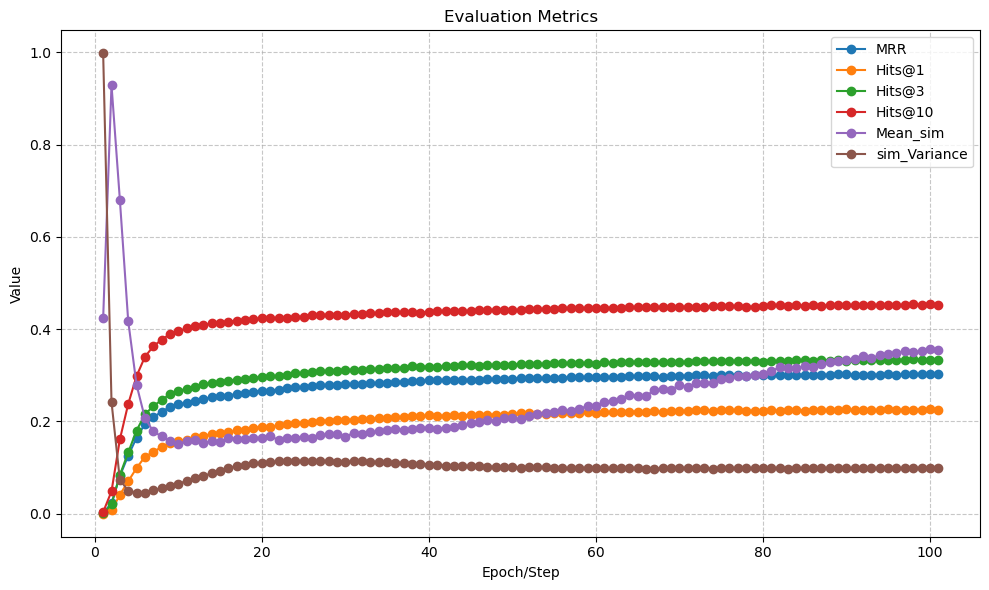

In [1]:
import re
import matplotlib.pyplot as plt

def parse_log(file_path):
    # 存储指标的列表
    metrics = {
        'MRR': [], 'Hits@1': [], 'Hits@3': [], 'Hits@10': [], 'Mean_sim': [], 'sim_Variance': []
        # 'Spearman': [], 'p-value': []
    }

    # 正则表达式匹配
    # 匹配第一行: Eval | MRR: ...
    eval_re = re.compile(r"Eval \| MRR: ([\d.]+) \| Hits@1: ([\d.]+) \| Hits@3: ([\d.]+) \| Hits@10: ([\d.]+) \| Mean Cosine Similarity: ([\d.]+) \| Cosine Similarity Variance: ([\d.]+)")
    # 匹配第二行: Spearman Correlation: ..., p-value: ...
    # corr_re = re.compile(r"Spearman Correlation: ([\d.-]+), p-value: ([\d.e-]+)")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            eval_match = eval_re.search(line)
            if eval_match:
                metrics['MRR'].append(float(eval_match.group(1)))
                metrics['Hits@1'].append(float(eval_match.group(2)))
                metrics['Hits@3'].append(float(eval_match.group(3)))
                metrics['Hits@10'].append(float(eval_match.group(4)))
                metrics['Mean_sim'].append(float(eval_match.group(5)))
                metrics['sim_Variance'].append(float(eval_match.group(6)))
                continue

    return metrics

def plot_metrics(data):
    epochs = range(1, len(data['MRR']) + 1)

    # 图 1: 主要指标 (MRR, Hits, Spearman)
    plt.figure(figsize=(10, 6))
    for key in ['MRR', 'Hits@1', 'Hits@3', 'Hits@10', 'Mean_sim', 'sim_Variance']:
        if data[key]:
            plt.plot(epochs, data[key], marker='o', label=key)
    
    plt.title('Evaluation Metrics')
    plt.xlabel('Epoch/Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    log_file_path = "../../log/rgcn.txt"  # <--- 修改为你的日志文件名
    extracted_data = parse_log(log_file_path)
    plot_metrics(extracted_data)

15、不带原型的自定义Encoder，各类指标曲线绘制

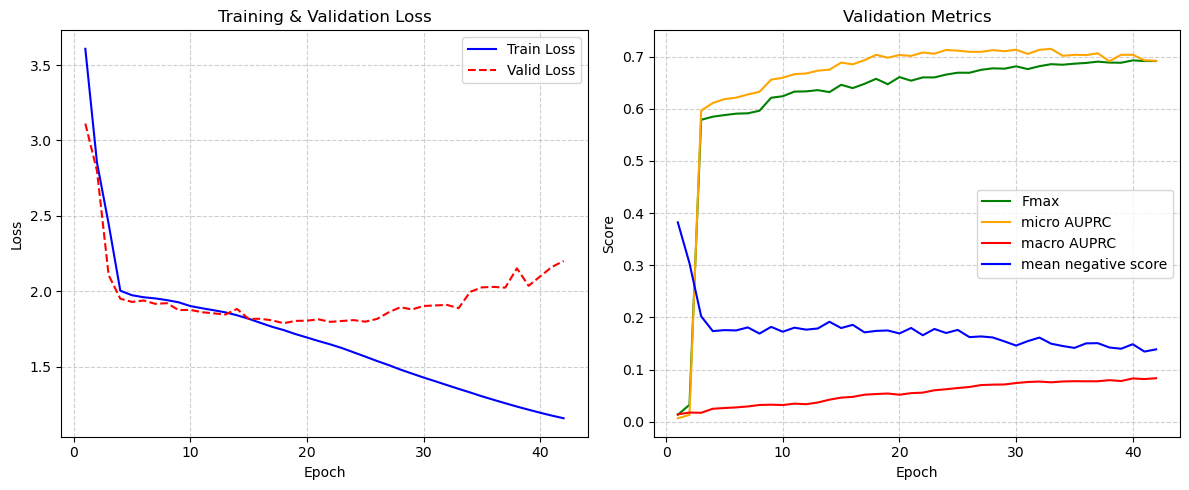

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

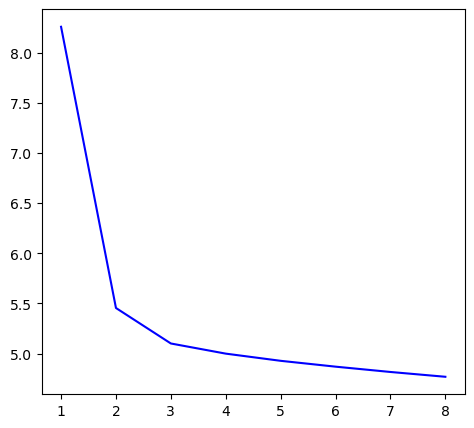

In [ ]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_log_metrics(log_file_path, is_loss_log=False):
    # 初始化存储数据的列表
    train_loss, val_loss = [], []
    fmax, micro_auprc, macro_auprc, mean_neg_score = [], [], [], []

    # 定义正则匹配模式
    train_pattern = re.compile(r"Averaged stats: .* total_loss: ([\d.]+)")
    val_pattern = re.compile(r"Averaged stats\(Valid\): total_loss: ([\d.]+), Fmax: ([\d.]+), micro AUPRC: ([\d.]+), macro AUPRC: ([\d.]+), mean negative score: ([\d.]+)")

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 注意：先匹配 Valid，因为它更具体
            val_match = val_pattern.search(line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                fmax.append(float(val_match.group(2)))
                micro_auprc.append(float(val_match.group(3)))
                macro_auprc.append(float(val_match.group(4)))
                mean_neg_score.append(float(val_match.group(5)))
                continue # 匹配到 Valid 后跳过，防止被下方 Train 模式二次匹配
            
            train_match = train_pattern.search(line)
            if train_match:
                train_loss.append(float(train_match.group(1)))

    # 对数化处理以更清晰地展示损失变化趋势
    eps = 1e-8
    train_loss = [np.log(x + eps) for x in train_loss]
    val_loss = [np.log(x + eps) for x in val_loss]

    epochs = range(1, len(train_loss) + 1)

    # 开始绘图
    plt.figure(figsize=(12, 5))

    # 图 1: Loss 曲线 (训练集 vs 验证集)
    eps = 1e-8
    if is_loss_log:
        train_loss = [np.log(x + eps) for x in train_loss]
        val_loss = [np.log(x + eps) for x in val_loss]
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', color='blue')
    plt.plot(epochs, val_loss, label='Valid Loss', color='red', linestyle='--')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 图 2: 验证集指标 (Fmax & AUPRC)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, fmax, label='Fmax', color='green')
    plt.plot(epochs, micro_auprc, label='micro AUPRC', color='orange')
    plt.plot(epochs, macro_auprc, label='macro AUPRC', color='red')
    plt.plot(epochs, mean_neg_score, label='mean negative score', color='blue')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_log_metrics("../../log/new.txt")
plot_log_metrics("../../log/mean_cc.txt")
plot_log_metrics("../../log/mean_mf.txt")
plot_log_metrics("../../log/max_cc.txt")
plot_log_metrics("../../log/max_mf.txt")
plot_log_metrics("../../log/max_bp.txt")
plot_log_metrics("../../log/attn_mf.txt")
plot_log_metrics("../../log/attn_cc.txt")
plot_log_metrics("../../log/attn_bp.txt")

16、pubmedBert初始化后节点特征可视化

平均余弦相似度：0.2937, 方差：0.2350
正在进行 t-SNE 降维 (输入维度: (45667, 768))...


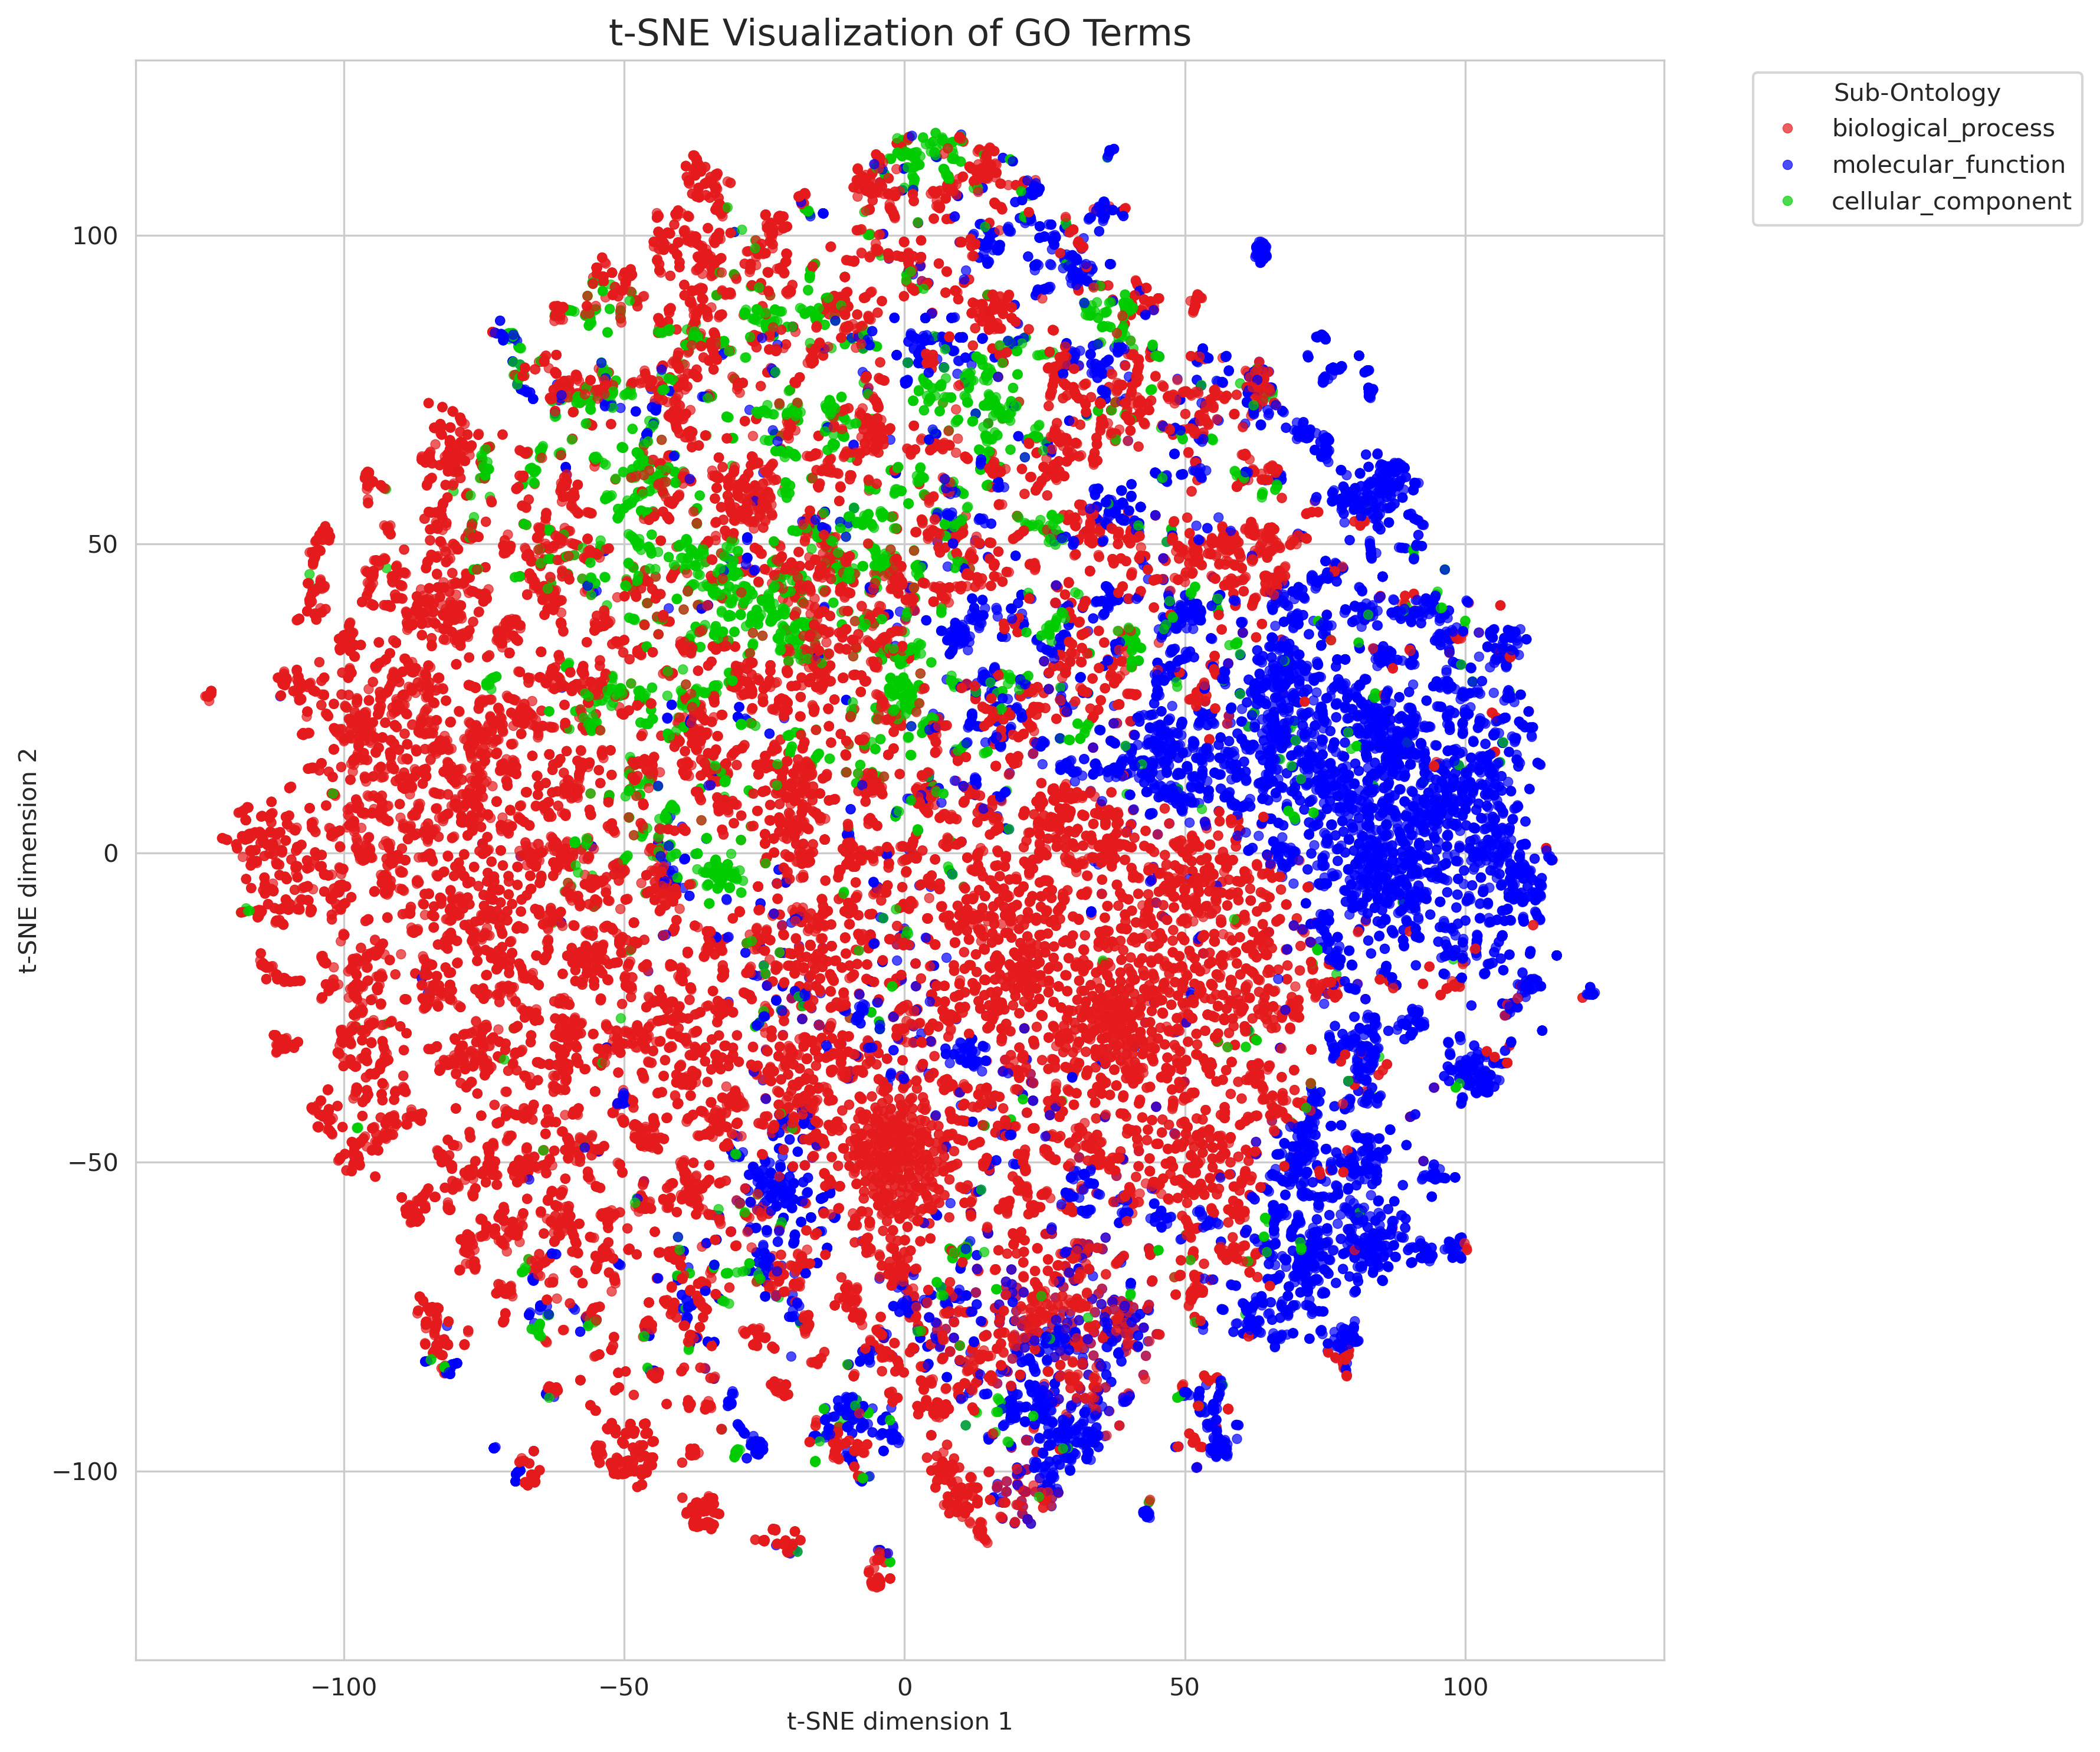

正在进行 t-SNE 降维 (输入维度: (53, 768))...


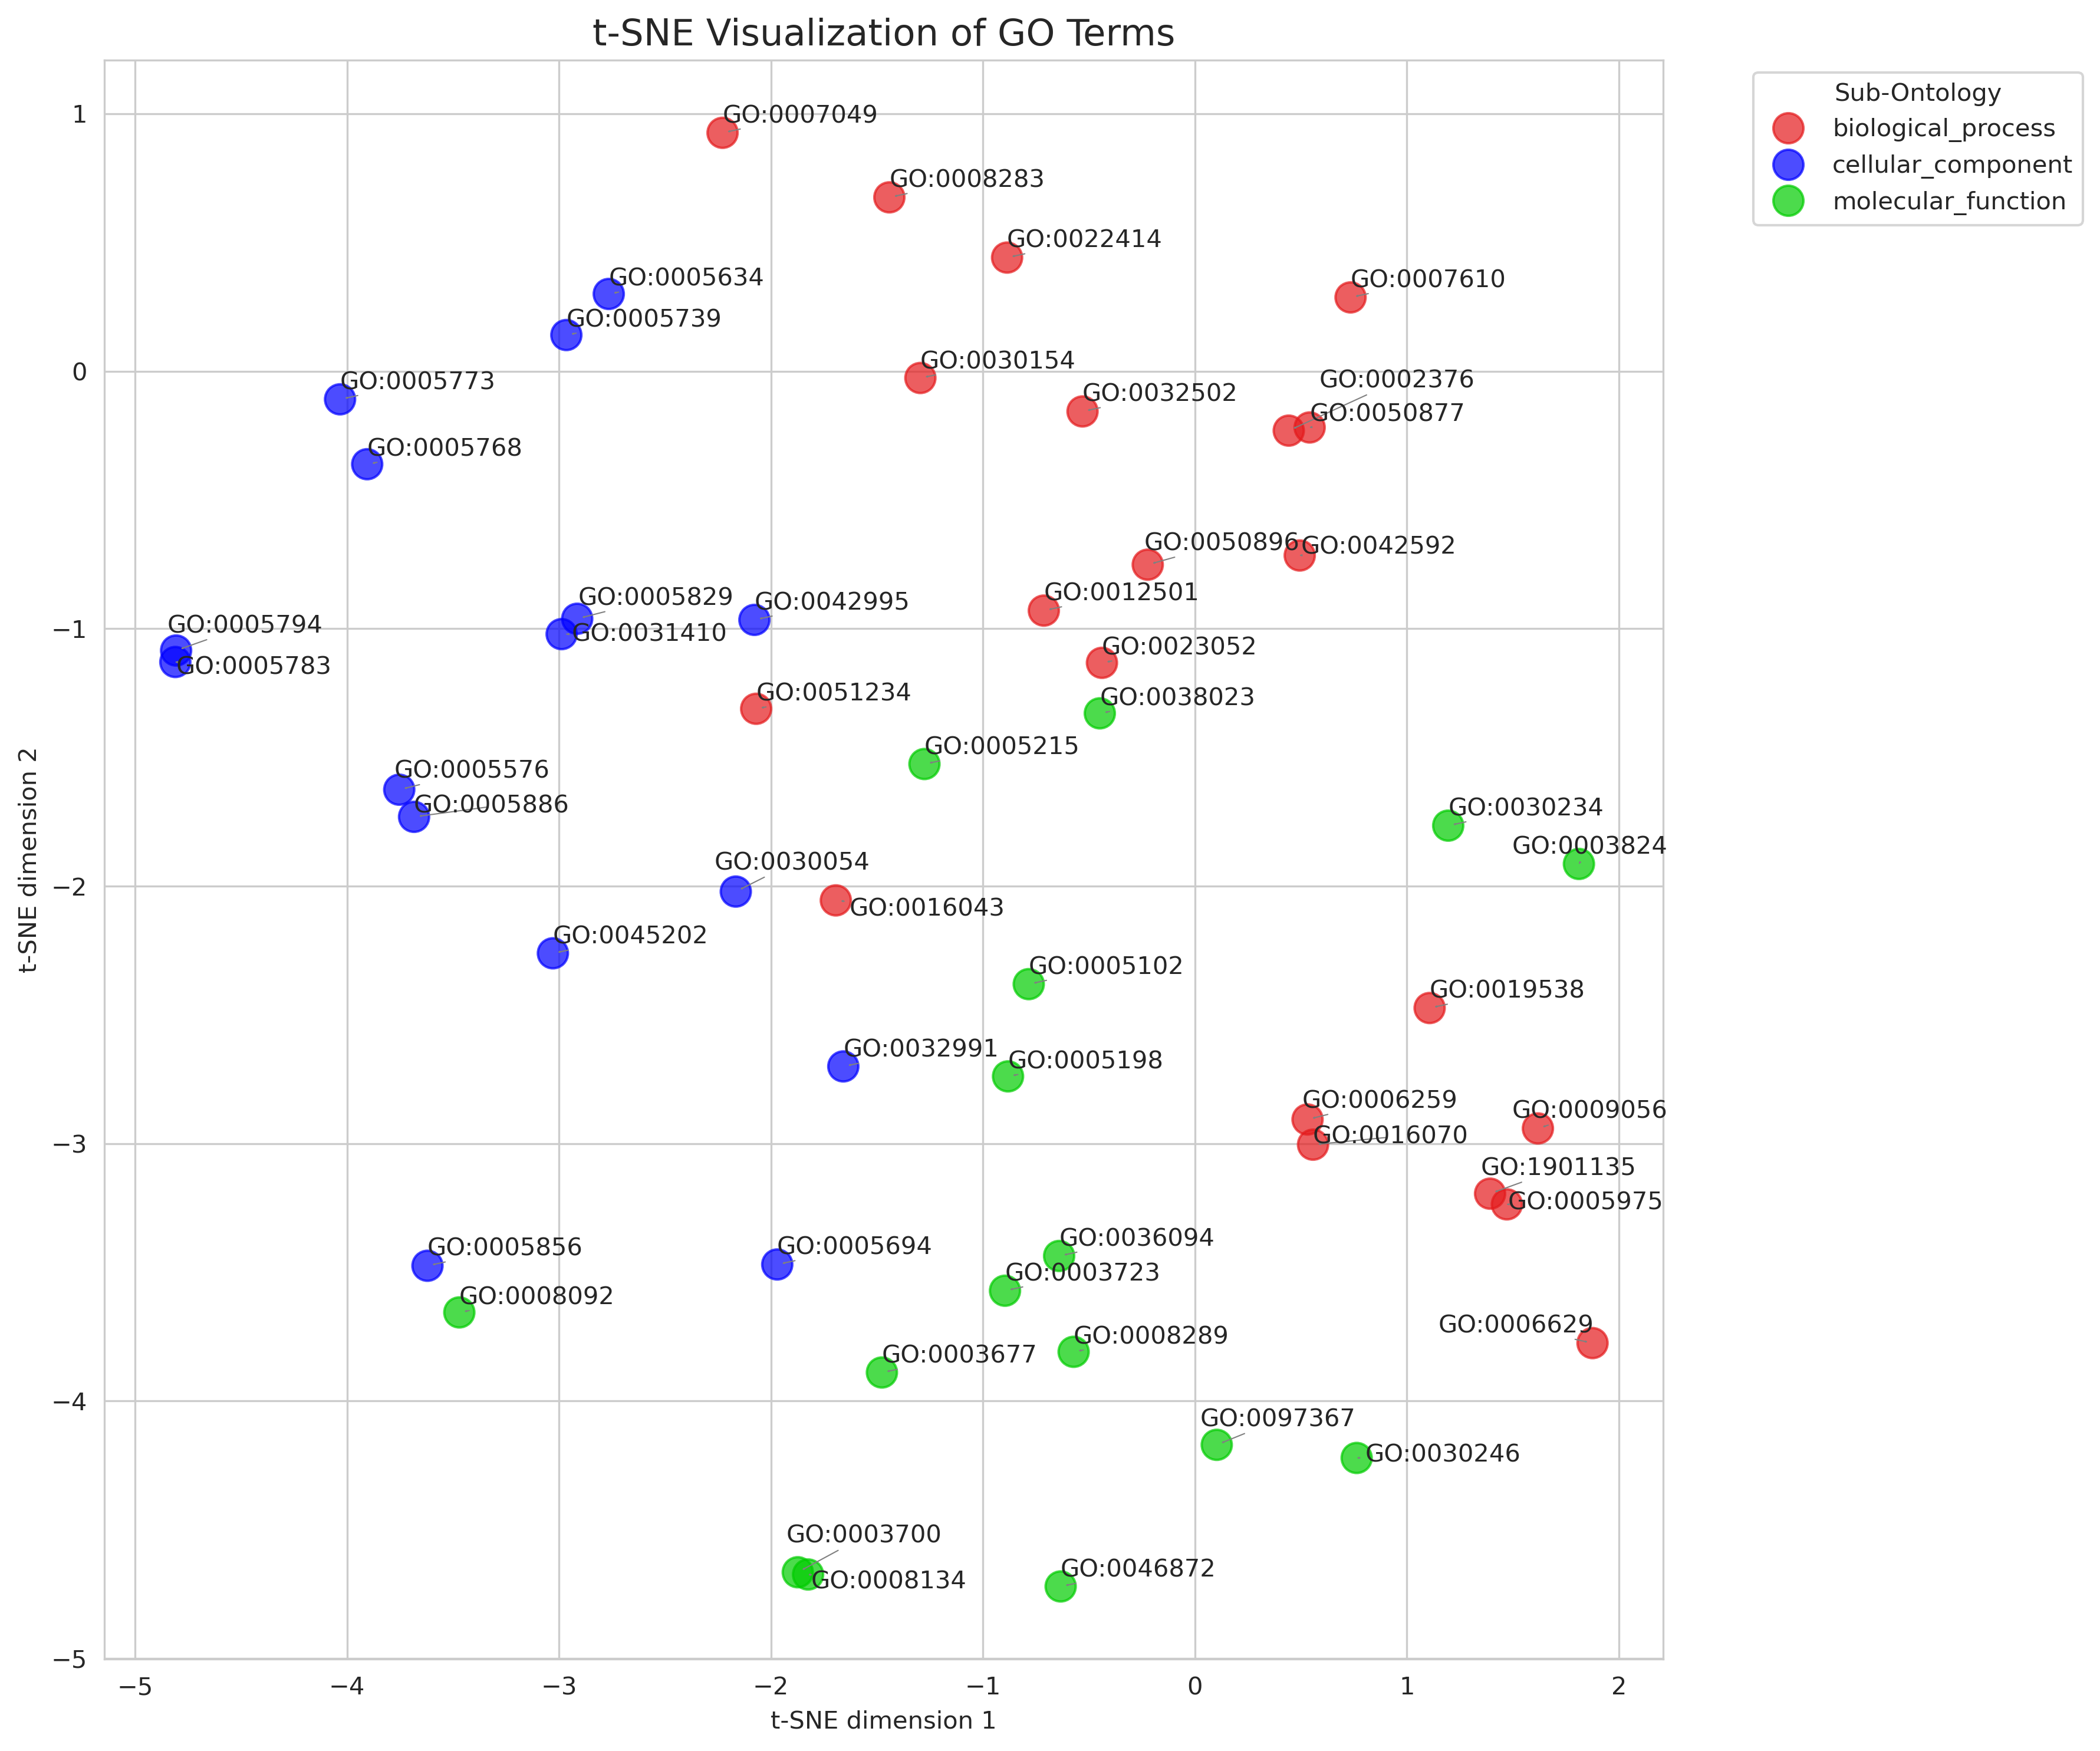

In [5]:
import utils
import torch

go2id = utils.load_id_mapping("./data/graph_node_id.txt")
namesapce_dict = utils.load_namespace("./data/graph_node_namespace.txt")
node_feat_path="./data/go_embeddings_init.pt"
node_feats = torch.load(node_feat_path, weights_only=True, map_location='cpu')

# # 随机采样计算平均余弦相似度，与其方差
mean_cos_sim, sim_variance = utils.compute_graph_metrics(node_feats, save_path = "/archive/hot3/fty/result/histogram/histogram_init", sample_size=(len(node_feats)//10))
print(f"平均余弦相似度：{mean_cos_sim:.4f}, 方差：{sim_variance:.4f}")

# 对go集合的全集可视化
utils.visualize_go_embeddings(node_feats, labels=[namespace for namespace in namesapce_dict.values()], names=list(go2id), save_path="/archive/hot3/fty/result/t-SNE/all/t-SNE_init", is_saveing_html=True)

# 对go集合的子集goslim_agr可视化
goslim_path = '/archive/hot3/fty/data/protein/goslim_agr.txt'
with open(goslim_path, 'r', encoding='utf-8') as f:
    go_terms = [line.rstrip('\n').split(' ')[0] for line in f]
slim_index = [go2id[go] for go in go_terms]
namespace_list = [namespace for namespace in namesapce_dict.values()]
namespace_slim_list = [namespace_list[i] for i in slim_index]
utils.visualize_go_embeddings(node_feats[slim_index], labels=namespace_slim_list, names=go_terms, save_path= "/archive/hot3/fty/result//t-SNE/slim/t-SNE_init", plot_size=150)

17、先处理数据得到go term和对应蛋白质的映射文件，用于计算原型。

In [1]:
import pickle
import numpy as np

def naive_predictor(train_seq_path, test_seq_path):
    """
    朴素预测器：将训练集中每个 GO 术语的出现频率（Prior）作为预测概率，
    对测试集中的每个蛋白质，返回相同的先验概率向量。

    Args:
        train_seq_path (str): 训练集 pickle 文件路径（如 data_tale/CAFA3/train_seq_cc）
        test_seq_path  (str): 测试集 pickle 文件路径（如 data_tale/CAFA3/test_seq_cc）

    Returns:
        predictions (np.ndarray): shape (num_test_proteins, num_go_terms)
        test_data  (list[dict]):  原始测试数据（含 ground truth labels）
    """
    # ————— 1. 加载训练数据 —————
    with open(train_seq_path, 'rb') as f:
        train_data = pickle.load(f)

    # ————— 2. 确定 GO term 总数（取所有 label 索引的最大值） —————
    max_label = 0
    for item in train_data:
        if item['label']:
            max_label = max(max_label, max(item['label']))
    num_go_terms = max_label + 1

    # ————— 3. 计算每个 GO term 的训练集出现频率（Prior） —————
    num_train = len(train_data)
    prior = np.zeros(num_go_terms, dtype=np.float32)
    for item in train_data:
        for lbl in item['label']:
            prior[lbl] += 1.0
    prior /= num_train  # 归一化到 [0, 1]

    # ————— 4. 加载测试数据 —————
    with open(test_seq_path, 'rb') as f:
        test_data = pickle.load(f)

    num_test = len(test_data)

    # ————— 5. 为每个测试蛋白质生成预测 —————
    predictions = np.tile(prior, (num_test, 1))  # (N_test, N_go)

    return predictions, test_data


def calculate_fmax(y_true, y_pred):
    """
    计算 protein-centric Fmax：对阈值 0.01~1.00（步长 0.01），
    求平均 per-protein precision/recall 下的最大 F1 值。

    Args:
        y_true (np.ndarray): 二值标签矩阵 (N_proteins, N_go_terms)
        y_pred (np.ndarray): 预测概率矩阵  (N_proteins, N_go_terms)

    Returns:
        float: Fmax 值
    """
    fmax = 0.0
    for t in range(1, 101):
        thres = t / 100.0
        pred_labels = (y_pred >= thres).astype(np.int32)

        tp = np.sum(pred_labels * y_true, axis=1)          # per-protein TP
        tpfp = np.sum(pred_labels, axis=1)                  # per-protein TP+FP
        tpfn = np.sum(y_true, axis=1)                       # per-protein TP+FN

        # 过滤掉预测全为 0 的蛋白质（避免除零）
        valid = tpfp > 0
        if not np.any(valid):
            continue

        avg_precision = np.mean(tp[valid] / tpfp[valid])
        avg_recall = np.mean(tp[valid] / tpfn[valid])
        f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall + 1e-12)

        fmax = max(fmax, f1)

    return fmax


def calculate_auprc(y_true, y_pred):
    """计算 micro AUPRC（使用 sklearn 标准实现）"""
    from sklearn.metrics import average_precision_score
    return average_precision_score(y_true.flatten(), y_pred.flatten())


# ==================== 主流程 ====================
predictions, test_data = naive_predictor(
    './data_tale/TALE/train_seq_cc',
    './data_tale/TALE/test_seq_cc'
)

print(f"预测矩阵形状: {predictions.shape}")
print(f"测试蛋白质数量: {len(test_data)}, GO term 总数: {predictions.shape[1]}")
print(f"Prior 范围: [{predictions.min():.4f}, {predictions.max():.4f}]")

# 构造真实标签矩阵 (N_test, N_go) — 二值矩阵
num_go = predictions.shape[1]
y_true = np.zeros((len(test_data), num_go), dtype=np.int32)
for i, item in enumerate(test_data):
    for lbl in item['label']:
        if lbl < num_go:
            y_true[i, lbl] = 1

# 过滤掉标签全为 0 的蛋白质（与项目内 calculate_metrics 保持一致）
mask = y_true.sum(axis=1) > 0
y_true_filtered = y_true[mask]
y_pred_filtered = predictions[mask]

fmax = calculate_fmax(y_true_filtered, y_pred_filtered)
micro_auprc = calculate_auprc(y_true_filtered, y_pred_filtered)

print(f"Fmax: {fmax:.4f}")
print(f"Micro AUPRC: {micro_auprc:.4f}")

预测矩阵形状: (2084, 2574)
测试蛋白质数量: 2084, GO term 总数: 2574
Prior 范围: [0.0000, 0.9999]
Fmax: 0.5992
Micro AUPRC: 0.5330


18、获取对应namespace下的数据集labels

In [15]:
import pickle

# 从 cc_go_1.pickle 获取 CC namespace 所有 GO term 字符串
with open('./data_tale/TALE/bp_go_1.pickle', 'rb') as f:
    cc_go = pickle.load(f)

# cc_go 的 key 就是 GO term 字符串，如 "GO:0000015"
cc_go_terms = set(cc_go.keys())

print(f"CC namespace GO term 总数: {len(cc_go_terms)}")
print(f"\n示例 GO term（前 10 个）: {sorted(list(cc_go_terms))[:10]}")
print(f"示例 GO term（后 10 个）: {sorted(list(cc_go_terms))[-10:]}")

# 也可以同时获取 name（人类可读名称）
print(f"\n--- 附带名称的示例 ---")
for go_term in sorted(list(cc_go_terms))[:5]:
    print(f"  {go_term}: {cc_go[go_term]['name']}")


CC namespace GO term 总数: 19939

示例 GO term（前 10 个）: ['GO:0000001', 'GO:0000002', 'GO:0000003', 'GO:0000011', 'GO:0000012', 'GO:0000017', 'GO:0000018', 'GO:0000019', 'GO:0000022', 'GO:0000023']
示例 GO term（后 10 个）: ['GO:2001305', 'GO:2001306', 'GO:2001307', 'GO:2001308', 'GO:2001310', 'GO:2001311', 'GO:2001313', 'GO:2001315', 'GO:2001316', 'GO:2001317']

--- 附带名称的示例 ---
  GO:0000001: mitochondrion inheritance
  GO:0000002: mitochondrial genome maintenance
  GO:0000003: reproduction
  GO:0000011: vacuole inheritance
  GO:0000012: single strand break repair


19、将 gene ontology 层次关系（parent→child 边）构建为邻接矩阵并保存
- 读取 `data_tale/TALE/{namespace}_label_regular_1.npy`（shape `[N_edges, 2]`，列0=父节点索引，列1=子节点索引）
- 构建稠密邻接矩阵 `[num_nodes, num_nodes]`，`adj[parent, child] = 1`
- 保存为 `.npy` 文件，可直接 `torch.from_numpy(np.load(...))` 加载

In [1]:
import numpy as np
import os


def build_adjacency_from_edges(edges: np.ndarray, num_nodes: int = None) -> np.ndarray:
    """
    根据 parent→child 边列表构建稠密邻接矩阵。

    Args:
        edges: shape [N_edges, 2], edges[:, 0]=parent, edges[:, 1]=child
        num_nodes: 节点总数。若为 None，自动取 max(edges)+1

    Returns:
        adj: shape [num_nodes, num_nodes], adj[parent, child] = 1
    """
    if num_nodes is None:
        num_nodes = int(edges.max()) + 1

    adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    parent = edges[:, 0]
    child = edges[:, 1]
    adj[parent, child] = 1.0
    return adj


def process_namespace(namespace: str, data_dir: str, output_dir: str):
    """
    完整流程：读取 {namespace}_label_regular_1.npy → 构建邻接矩阵 → 保存。

    Args:
        namespace: 'cc', 'bp', 或 'mf'
        data_dir:   npy 文件所在目录
        output_dir: 输出目录
    """
    file_path = os.path.join(data_dir, f'{namespace}_label_regular_1.npy')
    edges = np.load(file_path)  # shape: [N_edges, 2]

    adj = build_adjacency_from_edges(edges)

    output_path = os.path.join(output_dir, f'{namespace}_adj_matrix.npy')
    np.save(output_path, adj)

    print(f"[{namespace.upper()}] edges={edges.shape[0]}, "
          f"nodes={adj.shape[0]}, "
          f"density={adj.sum() / (adj.shape[0] ** 2):.6f}, "
          f"saved → {output_path}")
    return adj


# ==================== 执行 ====================
DATA_DIR = './data_tale/TALE'
OUTPUT_DIR = DATA_DIR  # 同目录保存

for ns in ['cc', 'bp', 'mf']:
    process_namespace(ns, DATA_DIR, OUTPUT_DIR)

# 验证：演示如何加载为 PyTorch Tensor
import torch
adj_cc = torch.from_numpy(np.load(os.path.join(OUTPUT_DIR, 'cc_adj_matrix.npy')))
print(f"\n[验证] cc_adj_matrix 加载为 Tensor: dtype={adj_cc.dtype}, shape={adj_cc.shape}, device={adj_cc.device}")
print(f"  非零边数: {adj_cc.sum().item()}")


[CC] edges=4347, nodes=2574, density=0.000656, saved → ./data_tale/TALE/cc_adj_matrix.npy
[BP] edges=39752, nodes=19939, density=0.000100, saved → ./data_tale/TALE/bp_adj_matrix.npy
[MF] edges=8116, nodes=6381, density=0.000199, saved → ./data_tale/TALE/mf_adj_matrix.npy

[验证] cc_adj_matrix 加载为 Tensor: dtype=torch.float32, shape=torch.Size([2574, 2574]), device=cpu
  非零边数: 4347.0
